# TP3 — Lire une suite, apprendre à se souvenir
## Réseaux récurrents, propagation des gradients et attention

Une image se présente d'abord à nous comme un tout. Pourtant, nous pouvons choisir de la parcourir, colonne après colonne, et demander à une machine de former peu à peu son jugement. Cette simple modification du regard fait apparaître une difficulté nouvelle : à chaque instant, l'observation présente doit rencontrer quelque trace des observations passées. Un réseau récurrent donne à cette trace la forme d'un état que chaque nouvelle entrée transforme. Nous chercherons à comprendre comment cet état se construit, mais aussi par quel chemin une erreur finale peut instruire les opérations qui l'ont précédée.

Nous suivrons ensuite une question voisine. Lorsqu'une machine doit produire une suite entière, lui suffit-il de résumer la source une fois pour toutes ? Peut-elle, au contraire, revenir vers les représentations qu'elle a formées et y choisir, à chaque pas, ce qui lui est utile ? La construction d'une fonction d'attention nous permettra de rendre cette interrogation précise, puis de la soumettre à l'expérience.

Le travail alterne ainsi trois gestes : **observer, prévoir, vérifier**. Avant d'exécuter une cellule, prenez le temps d'annoncer la forme du résultat que vous attendez. Une courbe devient instructive lorsque l'on peut dire quelle hypothèse elle confirme, laquelle elle fragilise et quelle expérience permettrait de les départager. Une assertion satisfaite établit une propriété limitée ; une bonne accuracy ne dispense pas d'expliquer ce qui a été appris.

Nous accorderons une place particulière aux expériences qui semblent d'abord décevantes. Un modèle qui progresse peu n'appelle pas nécessairement un réseau plus grand ; un modèle qui reconnaît parfaitement son training set n'a pas nécessairement découvert une règle générale. Devant ces deux situations, le travail scientifique commence par une description exacte du symptôme, puis par une hypothèse assez précise pour être contredite. Les réglages proposés vous permettront de provoquer ces comportements sans une longue recherche empirique. Ils constituent le point de départ de l'enquête, jamais sa conclusion. Conservez la trace d'une attente déçue : savoir expliquer pourquoi une idée ne résiste pas aux mesures est déjà un progrès.

| Séance | Parcours |
|---|---|
| 1 | Reconnaître un chiffre au fil de ses colonnes ; suivre le retour du gradient |
| 2 | Produire une suite et apprendre où regarder |

Les cellules de service sont écrites ; les passages à construire portent les repères **C1 à C5**, soit neuf lignes ciblées. Les équations en donnent le sens, tandis que les commentaires indiquent les tenseurs à manipuler. Les questions **Q1 à Q10** appellent des réponses structurées : une observation précise, une interprétation et, lorsque plusieurs explications restent possibles, une expérience pour les départager. Les cellules du carnet d'essais accueillent ce raisonnement avant et après la modification d'un hyperparamètre.

**Environnement.** Importez ce fichier dans Colab et choisissez un environnement CPU. Les données sont disponibles dans scikit-learn ou engendrées par le notebook. Exécutez les cellules dans leur ordre. Un `NotImplementedError` indique une ligne à compléter ; remplacez cette instruction par votre calcul. Pour commencer directement la seconde séance, exécutez le socle commun, puis rendez-vous à l'exercice 3. Enregistrez régulièrement votre travail.

**Cahier étudiant.**

## Socle commun — donner à l’expérience des conditions reproductibles

Nous fixons les seeds aléatoires afin de pouvoir attribuer autant que possible une différence de résultat à la modification que nous avons choisie. Cette précaution rend une comparaison plus lisible ; elle ne transforme pas une exécution unique en résultat universel. Le calcul se fera sur CPU, avec deux fils d'exécution. Les figures, les tenseurs et les métriques seront produits avec les mêmes bibliothèques dans les trois exercices.

**Repère de lecture du code.** Une variable intermédiaire nomme chaque étape importante. Lisez les blocs dans leur ordre, puis comparez la forme annoncée dans le commentaire à celle du tenseur. Les fonctions de préparation, de mesure et de training occupent des cellules séparées. Les schémas intégrés peuvent être consultés sans exécuter ces cellules.

In [ ]:
# Seulement si un import échoue dans un environnement autre que Colab :
# %pip install torch numpy matplotlib scikit-learn
import math
import random
import sys
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence,
)
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

torch.set_num_threads(2)
DEVICE = torch.device("cpu")


def seed_all(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


seed_all()
plt.rcParams.update(
    {"figure.figsize": (8, 3), "axes.grid": True, "font.size": 10}
)
print(
    "Python",
    sys.version.split()[0],
    "| PyTorch",
    torch.__version__,
    "|",
    DEVICE,
)

## Exercice 1 — Reconnaître un chiffre au fil de ses colonnes
### La question, les données et l’instrument de mesure

**But de l'expérience.** Nous voulons construire un classifieur qui accepte une suite de longueur variable sans changer de paramètres lorsque cette longueur change. Pour cela, nous parcourrons un chiffre manuscrit de gauche à droite. Chaque colonne apportera une observation nouvelle ; le hidden state du réseau devra en conserver une représentation utile jusqu'à la décision finale. Il s'agira de comprendre ensemble la récurrence, le partage des poids et la distinction entre une observation et une case ajoutée pour former un batch.

**Données.** Le jeu *Digits* contient 1 797 images de chiffres, chacune composée de 8×8 pixels dont l'intensité appartient à $\{0,\ldots,16\}$. Nous divisons les intensités par 16, puis retirons seulement les colonnes entièrement nulles situées aux deux bords. Une image devient ainsi une suite $X=(x_1,\ldots,x_\ell)$, où $x_t\in\mathbb R^8$, associée à un label $y\in\{0,\ldots,9\}$. Il s'agit d'un parcours spatial ordonné : la longueur décrit la largeur conservée du dessin. La transformation utilise uniquement les pixels. Nous réservons 25 % des images à la validation, en conservant approximativement les proportions des dix classes dans les deux ensembles.

**Modèle et description formelle.** Le réseau récurrent possède un hidden state de dimension $H$. Avec des vecteurs colonnes et $h_0=0$, son fonctionnement s'écrit
$$\widetilde h_t=\tanh(W_xx_t+W_hh_{t-1}+b_h),\qquad
h_t=m_t\widetilde h_t+(1-m_t)h_{t-1},$$
$$z=W_oh_{T_{\max}}+b_o,\qquad
p_\theta(y=k\mid X)=\frac{e^{z_k}}{\sum_{j=0}^{9}e^{z_j}}.$$
Pour un exemple de longueur $\ell$, $m_t=\mathbf1[t\leq\ell]$. Les cases suivantes sont du *padding* ; le masque y conserve l'état précédent, si bien que $h_{T_{\max}}=h_\ell$. Les paramètres ont les dimensions $W_x\in\mathbb R^{H\times8}$, $W_h\in\mathbb R^{H\times H}$ et $W_o\in\mathbb R^{10\times H}$. Ils sont identiques à chaque pas. Dans le code, les indices commencent à zéro et les batches sont représentés par des vecteurs lignes ; `nn.Linear` effectue la transposition nécessaire.

**Choisir la loss et les métriques.** Les dix labels désignent des catégories : leur différence numérique n'exprime pas une distance entre dessins. Nous optimisons donc la cross-entropy, c'est-à-dire la log-vraisemblance négative moyenne de la classe correcte,
$$\mathcal L_{\mathrm{CE}}(\theta;\mathcal D)
=-\frac1{|\mathcal D|}\sum_{(X,y)\in\mathcal D}\log p_\theta(y\mid X).$$
Pour la validation, nous calculons cette même loss et l'accuracy $A=|\mathcal D|^{-1}\sum\mathbf1[\arg\max_k z_k=y]$. La première tient compte de la probabilité donnée à la bonne classe ; la seconde répond à la question concrète : combien de chiffres ont été reconnus ? Une accuracy constante peut ainsi accompagner une évolution sensible de la confiance du modèle. `cross_entropy` reçoit directement les logits $z$, et non des probabilités déjà normalisées.

**Hyperparamètres.** Ce sont les choix que nous fixons pour le training, tandis que les matrices et les biais sont ajustés par l'optimizer.

| Choix | Valeur de départ | Rôle dans l’expérience |
|---|---:|---|
| Hidden size $H$ | 32 | Taille de la représentation mémorisée |
| Batch size $B$ | 64 | Nombre d'exemples par estimation du gradient |
| Optimizer | Adam | Règle de update des paramètres |
| Learning rate $\eta$ | $10^{-5}$ puis 0,004 | Comparaison d'un pas très faible et de sa correction |
| Nombre d'epochs | 12 | Nombre de parcours du training set |
| Seuil de clipping | 1 | Borne de la norme globale des gradients avant l'update |
| Seeds de split et de training | 42 | Reproductibilité du protocole |

Nous commencerons par comparer $\eta=10^{-5}$ et $\eta=0{,}004$ dans les mêmes conditions. Nous examinerons ensuite un second régime, avec 60 exemples de training, $H=64$, $\eta=0{,}01$ et 100 epochs, puis nous essaierons un arrêt plus précoce. Ces deux situations permettront de distinguer un modèle qui n'a pas encore appris suffisamment d'un modèle qui s'ajuste très bien à ses observations, mais ne généralise plus aussi bien. Les valeurs proposées rendent l'expérience accessible ; elles ne dispensent pas d'établir le diagnostic à partir des données et des learning curves.

**Lire le schéma.** Sur cet exemple à quatre classes, les deux modèles choisissent le bon label. Leur accuracy est donc identique, mais la cross-entropy distingue la confiance accordée à la réponse correcte. Revenez aux deux nombres de la figure lorsque vous rencontrerez une accuracy stable et une loss qui évolue.

$$\hat y=\arg\max_k p_k,\qquad A=\mathbf1[\hat y=y],\qquad\mathcal L=-\log p_y.$$

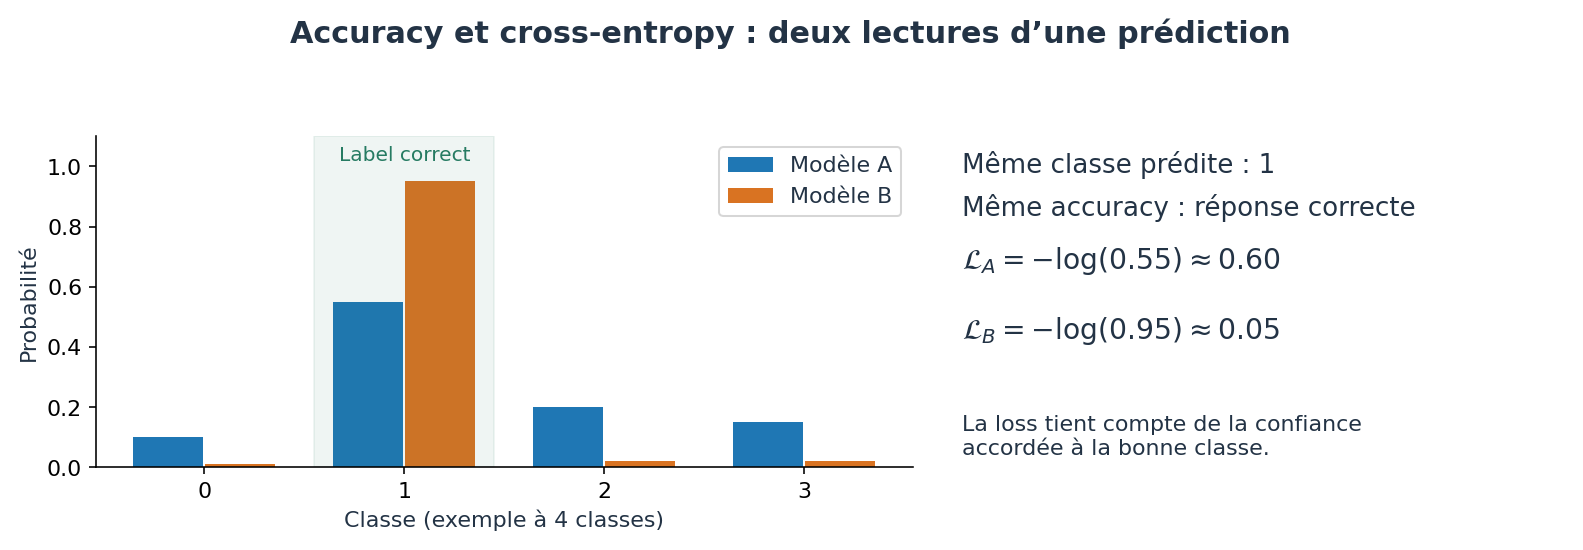

### 1.1 — Voir les données, puis établir la séparation

Observez d'abord les dessins. En supprimant les marges vides, avons-nous changé le chiffre ou seulement le domaine sur lequel nous le parcourons ? Regardez ensuite les longueurs obtenues. Pour réunir des suites différentes dans un tenseur rectangulaire, `pad_sequence` ajoute des colonnes nulles après leur fin. Une ligne rouge marque cette frontière sur la figure : à sa droite, il reste des cases dans le tableau, mais aucune nouvelle observation.

La cellule construit une séparation stratifiée et affiche ses effectifs. Le facteur de normalisation, 16, vient de l'échelle connue des pixels ; il n'est pas estimé sur la validation. Nous conserverons les indices de séparation pour que toute comparaison de réglage porte sur les mêmes exemples. Le masque sera déduit des longueurs, et non de l'intensité des pixels : une colonne nulle située à l'intérieur du dessin reste une observation légitime.

Ne laissez pas l'existence d'un dataset classique vous dispenser de le regarder. Demandez-vous ce que ces pixels montrent encore après normalisation et retrait des marges, quelles variations d'écriture pourraient rendre la décision ambiguë et si les quelques images affichées suffisent à représenter l'ensemble. Une visualisation est un échantillon de la réalité ; lorsque vous en tirez une impression générale, dites sur combien d'exemples elle repose. Vous retrouverez cette prudence en examinant les erreurs du modèle : un score global peut être satisfaisant tout en dissimulant une difficulté récurrente sur certaines formes.

**Q1.** Relevez les tailles du batch, des longueurs et des labels. Expliquez pourquoi les zéros ajoutés ne peuvent pas être traités comme de nouvelles observations. Quelle propriété de la prédiction doit rester vraie si l'on ajoute encore trois colonnes de padding ?

**Lire le schéma.** Suivez une colonne dans l'image, puis retrouvez-la comme un vecteur de huit composantes dans la séquence. L'axe temporel du tenseur est ici un axe de parcours spatial. Le PAD ajoute une case au tableau ; le masque indique qu'aucune observation ne doit y faire évoluer l'état.

$$X\in\mathbb R^{B\times T_{\max}\times8},\qquad m_{b,t}=\mathbf1[t<\ell_b]\quad\text{(indices Python).}$$

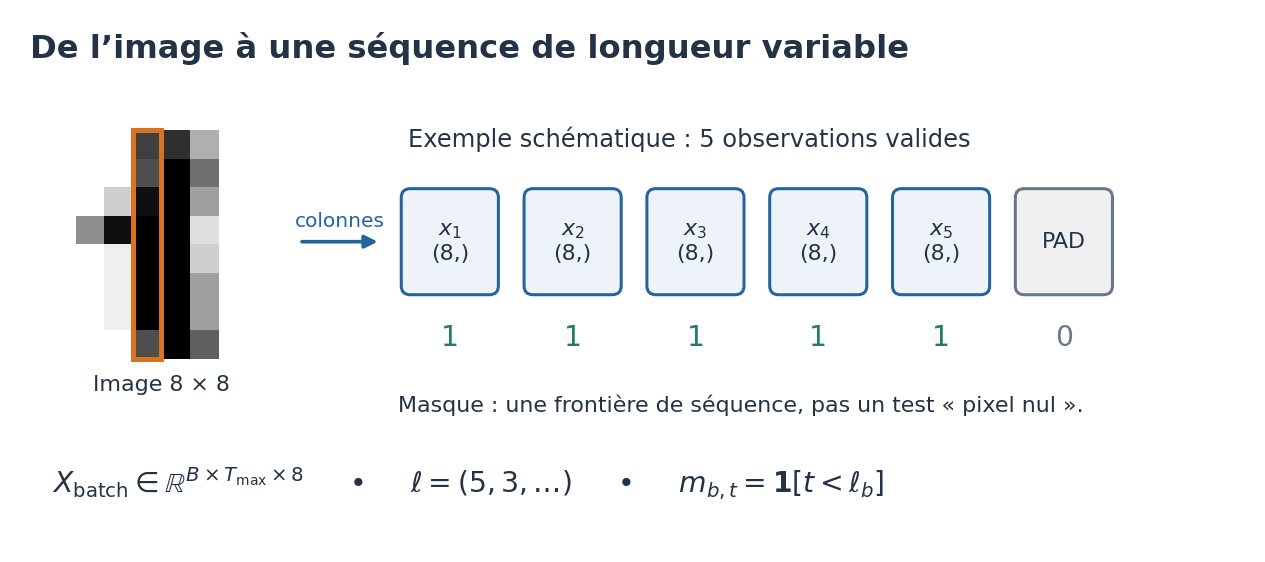

**Lire le schéma.** Les deux branches ont des responsabilités différentes. La branche de training produit les gradients qui modifient les poids ; la validation aide à juger ces poids et à choisir des réglages. Déplacer un exemple entre ces branches pendant les essais changerait l'expérience que vous cherchez à comparer.

$$\mathcal D_{\mathrm{train}}\cap\mathcal D_{\mathrm{val}}=\varnothing.$$

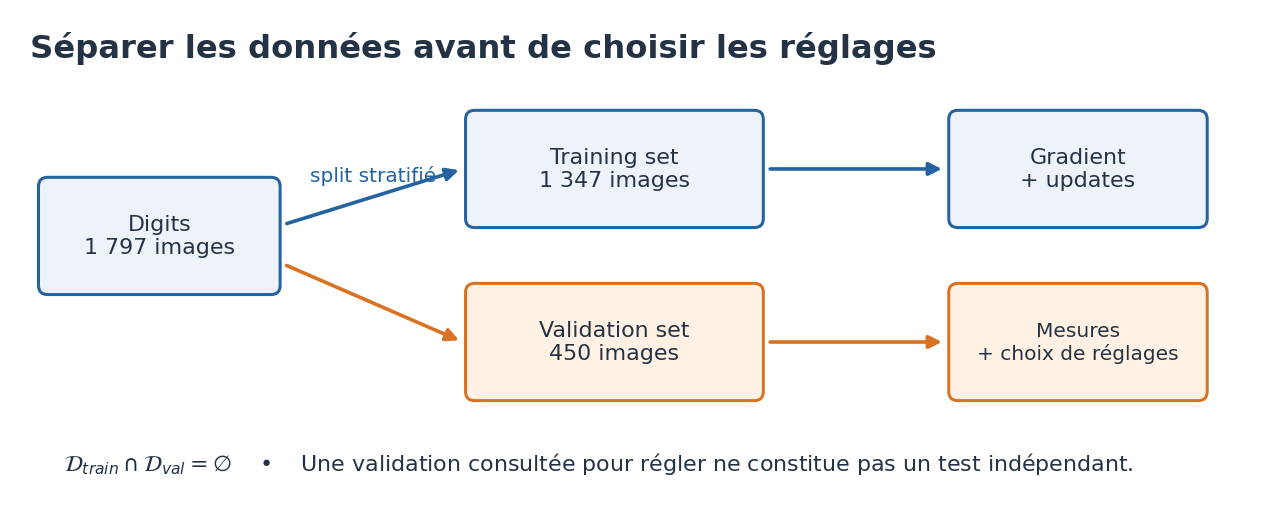

In [ ]:
# 1. Charger les images et transformer chaque image en séquence.
digits = load_digits()


def image_to_sequence(image):
    column_contains_ink = np.any(image != 0, axis=0)
    nonzero_columns = np.flatnonzero(column_contains_ink)

    first_column = nonzero_columns[0]
    last_column = nonzero_columns[-1]
    cropped_image = image[:, first_column : last_column + 1]

    # Une ligne du tenseur correspond à une colonne de l'image.
    sequence = cropped_image.T / 16.0
    return torch.tensor(sequence, dtype=torch.float32)


sequences = []
for image in digits.images:
    sequence = image_to_sequence(image)
    sequences.append(sequence)

# 2. Garder les mêmes partitions dans toutes les expériences.
all_indices = np.arange(len(sequences))
idx_train, idx_val = train_test_split(
    all_indices,
    test_size=0.25,
    stratify=digits.target,
    random_state=42,
)

In [ ]:
def digit_collate(items):
    batch_sequences, batch_labels = zip(*items)

    sequence_lengths = []
    for sequence in batch_sequences:
        sequence_lengths.append(len(sequence))

    padded_sequences = pad_sequence(batch_sequences, batch_first=True)
    lengths = torch.tensor(sequence_lengths)
    labels = torch.tensor(batch_labels)

    return padded_sequences, lengths, labels


def digit_loader(indices, shuffle=False):
    examples = []
    for index in indices:
        sequence = sequences[index]
        label = int(digits.target[index])
        examples.append((sequence, label))

    random_generator = torch.Generator().manual_seed(42)
    return DataLoader(
        examples,
        batch_size=64,
        shuffle=shuffle,
        collate_fn=digit_collate,
        generator=random_generator,
    )


dl_train = digit_loader(idx_train, shuffle=True)
dl_val = digit_loader(idx_val)
xb, lengths, yb = next(iter(dl_train))

assert set(idx_train).isdisjoint(set(idx_val))
assert len(set(idx_train) | set(idx_val)) == len(sequences)

print("Training set :", len(idx_train), "| validation :", len(idx_val))
print("Batch :", xb.shape, "| longueurs :", lengths[:16].tolist())

all_lengths = [len(sequence) for sequence in sequences]
length_values, length_counts = np.unique(all_lengths, return_counts=True)
print("Effectifs par longueur :", dict(zip(length_values, length_counts)))

fig, axes = plt.subplots(1, 3, figsize=(9, 2.6))
for index, axis in enumerate(axes):
    axis.imshow(xb[index].T.numpy(), cmap="gray", vmin=0, vmax=1)
    axis.axvline(lengths[index].item() - 0.5, color="tab:red")
    axis.set_title(f"Chiffre {yb[index]} ; longueur {lengths[index]}")
    axis.grid(False)

plt.tight_layout()
plt.show()

**Vos observations et votre réponse à Q1 :** …

### 1.2 — Construire la récurrence et vérifier les dimensions

La classe suivante sépare les trois transformations : `wx` traite l'observation, `wh` traite l'état précédent, et `head` transforme le dernier état en dix scores. **C1 :** écrivez le nouvel état candidat, puis choisissez, pour chaque exemple, s'il doit remplacer l'état précédent. Le masque de forme `(B,1)` s'applique par diffusion aux $H$ composantes de l'état. `torch.where(condition, a, b)` permet d'exprimer cette sélection sans parcourir les exemples un à un.

Avant toute descente de gradient, vérifiez ce que chaque transformation peut recevoir et produire :

| Grandeur | Forme attendue |
|---|---|
| Batch d'observations | `(B, T_max, 8)` |
| Observation à un pas | `(B, 8)` |
| État caché et état candidat | `(B, H)` |
| Masque à un pas | `(B, 1)` |
| Logits finaux | `(B, 10)` |

Les options `trace` et `truncate` préparent l'étude du gradient dans l'exercice suivant. Pour le training du classifieur, nous conservons leurs valeurs par défaut. Les assertions vérifient la forme de sortie et l'invariance au padding ; si elles échouent, examinez d'abord les axes manipulés plutôt que les hyperparamètres.

**Lire le schéma.** Chaque boîte est une valeur de l'état à un pas différent, et non un nouveau jeu de paramètres. Les mêmes symboles de poids reviennent sur les flèches parce que la même transformation est appliquée à chaque observation. À droite, la tête transforme le dernier état valide en logits de classification.

$$\widetilde h_t=\tanh(W_xx_t+W_hh_{t-1}+b_h),\qquad h_t=m_t\widetilde h_t+(1-m_t)h_{t-1}.$$

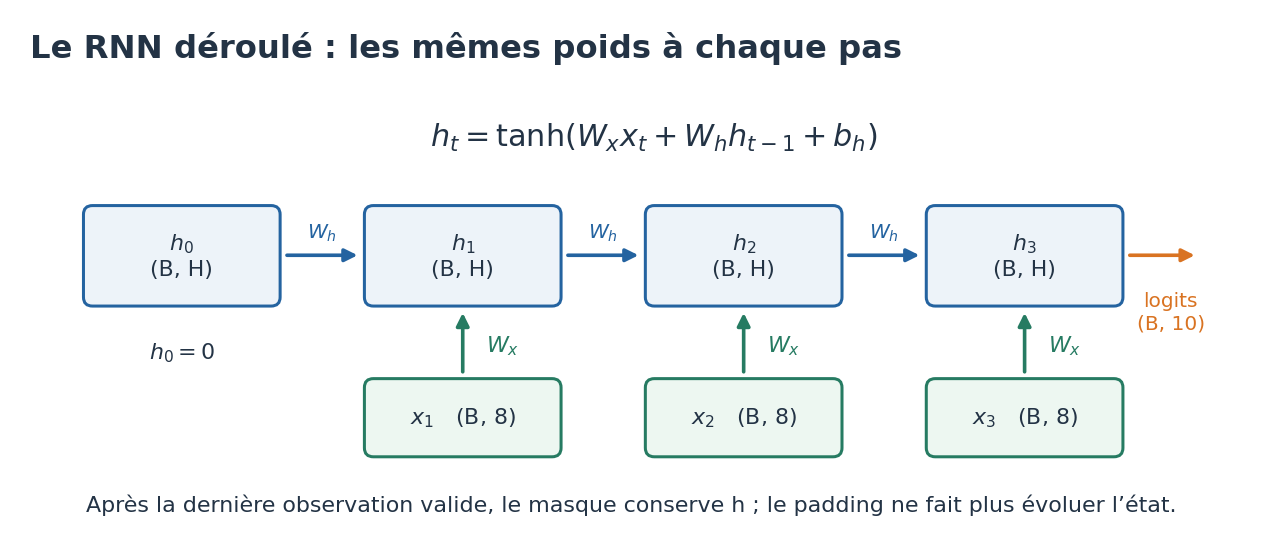

In [ ]:
class ManualRNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()

        self.hidden = hidden
        self.wx = nn.Linear(8, hidden)
        self.wh = nn.Linear(hidden, hidden, bias=False)
        self.head = nn.Linear(hidden, 10)

    def forward(self, x, lengths, trace=False, truncate=None):
        batch_size = x.shape[0]
        num_steps = x.shape[1]

        hidden = x.new_zeros(batch_size, self.hidden)
        states = []

        for step in range(num_steps):
            # Cette option sert seulement à l'expérience sur le gradient.
            if truncate is not None:
                cut_position = num_steps - truncate
                if step == cut_position:
                    hidden = hidden.detach()

            current_input = x[:, step, :]
            input_contribution = self.wx(current_input)
            hidden_contribution = self.wh(hidden)

            # C1a : proposer un nouvel état à partir des deux contributions.
            raise NotImplementedError("C1a : calculer candidate")

            # Le masque a la forme (B, 1), l'état la forme (B, H).
            active_examples = step < lengths
            active_mask = active_examples.unsqueeze(1)

            # C1b : ne changer que les états des exemples encore actifs.
            raise NotImplementedError("C1b : appliquer le masque")

            if trace:
                hidden.retain_grad()
                states.append(hidden)

        logits = self.head(hidden)

        if trace:
            return logits, states
        return logits


seed_all()
rnn = ManualRNN().to(DEVICE)

logits = rnn(xb, lengths)
expected_shape = (len(xb), 10)
assert logits.shape == expected_shape

# Ajouter du padding ne doit pas changer les logits.
extra_padding = F.pad(xb, (0, 0, 0, 3))
logits_with_padding = rnn(extra_padding, lengths)
assert torch.allclose(logits, logits_with_padding, atol=1e-6)

print("C1 : formes et invariance au padding validées.")

### 1.3 — Construire la training loop

Une epoch est un parcours complet des exemples de training. À chaque batch, nous effaçons les gradients de l'update précédente, calculons les logits et la loss, puis demandons à `backward()` de former les dérivées. Le clipping intervient après ce calcul et avant `step()`. L'optimizer peut alors déplacer les paramètres. Cet ordre traduit une chaîne de causes précise : observer une erreur, en mesurer la sensibilité, borner éventuellement l'update, puis agir.

La validation demande une autre discipline. Les paramètres restent fixes, et aucun graphe de dérivation n'est conservé. À la fin de chaque epoch, nous recalculons aussi les métriques sur le training set avec ces mêmes paramètres fixes. Les learning curves train/validation sont ainsi comparables : elles correspondent au même instant du modèle, plutôt qu'à une moyenne d'erreurs mesurées pendant que les poids se déplaçaient. Parcourez les deux fonctions ci-dessous et retrouvez chacune de ces étapes dans le code.

Avant toute interprétation, vérifiez que les deux courbes mesurent bien la même quantité : même loss, même convention de moyenne, mêmes classes et même normalisation des entrées. Un écart artificiel dans le protocole peut imiter un problème de généralisation. C'est ensuite seulement que vous pourrez discuter le niveau des losses, leur pente et leur écart. Un niveau élevé indique une difficulté ; une pente encore descendante suggère qu'une progression reste possible ; un écart qui s'élargit durablement invite à examiner l'overfitting. Aucun de ces indices ne doit être lu séparément des autres.

**Lire le schéma.** Parcourez la boucle dans le sens des flèches. Le calcul du gradient précède son clipping, qui précède l'update. La branche de validation réalise les mesures avec les poids obtenus, sans appeler l'optimizer. Dans le code, chaque étape porte un nom et occupe une instruction distincte.

$$g=\nabla_\theta\mathcal L_{\mathrm{batch}},\qquad \widetilde g=g\min\!\left(1,\frac{\tau}{\lVert g\rVert_2}\right),\qquad\theta_{\mathrm{nouveau}}=\operatorname{AdamUpdate}(\theta,\widetilde g).$$

La formule du clipping suppose un gradient non nul ; le gradient nul reste nul. Adam utilise également son état interne.

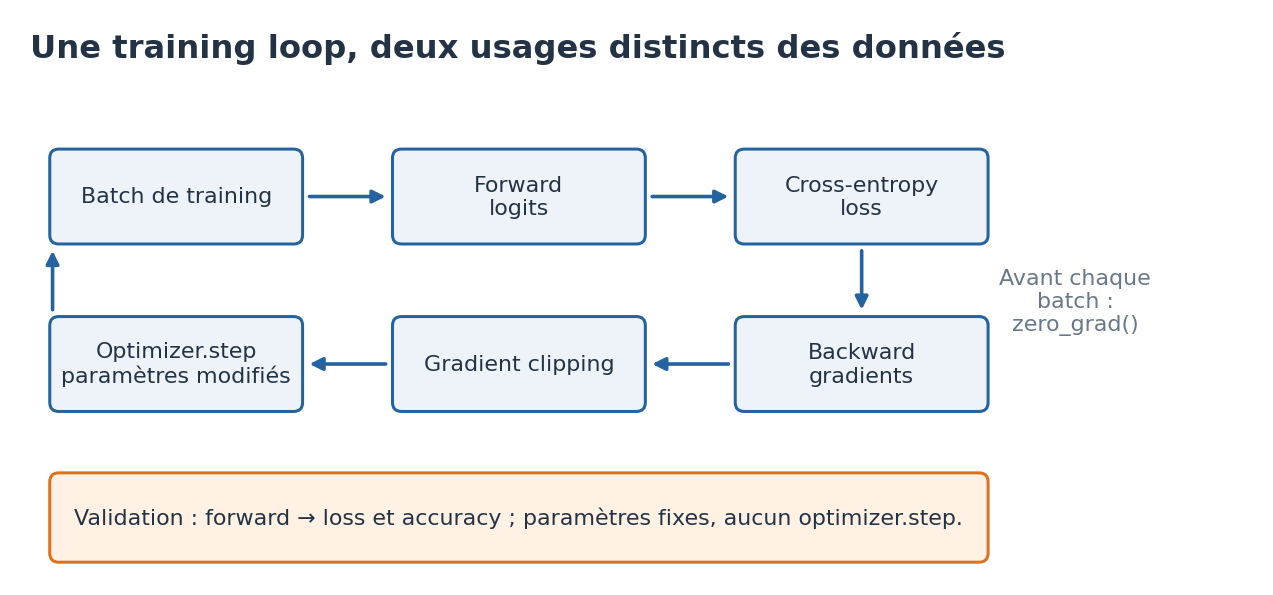

In [ ]:
@torch.no_grad()
def digit_metrics(model, loader):
    model.eval()

    total_loss = 0.0
    num_correct = 0
    num_examples = 0

    for inputs, lengths, labels in loader:
        logits = model(inputs, lengths)
        batch_loss = F.cross_entropy(logits, labels, reduction="sum")
        predictions = logits.argmax(dim=-1)

        total_loss += batch_loss.item()
        num_correct += (predictions == labels).sum().item()
        num_examples += len(labels)

    mean_loss = total_loss / num_examples
    accuracy = num_correct / num_examples
    return mean_loss, accuracy

In [ ]:
def fit_digits(lr, hidden=32, epochs=12, clip=1.0, train_indices=None):
    seed_all(42)

    if train_indices is None:
        indices = idx_train
    else:
        indices = np.asarray(train_indices)

    assert set(indices).issubset(set(idx_train))

    model = ManualRNN(hidden=hidden)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    training_loader = digit_loader(indices, shuffle=True)
    training_eval_loader = digit_loader(indices)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(epochs):
        model.train()

        for inputs, lengths, labels in training_loader:
            # Effacer les gradients du batch précédent.
            optimizer.zero_grad(set_to_none=True)

            # Forward : calculer les scores puis une loss scalaire.
            logits = model(inputs, lengths)
            loss = F.cross_entropy(logits, labels)

            # Backward : calculer, borner, puis utiliser les gradients.
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip)
            optimizer.step()

        # Mesurer train et validation avec les poids de fin d'epoch.
        train_loss, train_acc = digit_metrics(model, training_eval_loader)
        val_loss, val_acc = digit_metrics(model, dl_val)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    print(
        f"n_train={len(indices)}, H={hidden}, lr={lr:g}, epochs={epochs}"
        f" | CE train/val : {train_loss:.3f}/{val_loss:.3f}"
        f" | accuracy train/val : {train_acc:.1%}/{val_acc:.1%}"
    )
    return model, history

### 1.4 — Première enquête : le modèle apprend-il réellement ?

Commençons par un learning rate de $10^{-5}$, avec douze epochs et tous les exemples du training set. Une valeur faible peut sembler prudente : elle promet des déplacements modestes et laisse espérer une progression régulière. Mais la prudence n'est utile que si elle permet encore d'avancer. Regardez les deux losses ensemble, puis demandez-vous si le modèle distingue les chiffres ou s'il distribue encore ses probabilités presque indifféremment entre les dix classes. La référence $\log(10)\simeq2{,}30$ est la cross-entropy d'une distribution uniforme ; une accuracy proche de 10 % fournit un second point de comparaison.

**Avant d'exécuter la correction, écrivez votre diagnostic.** Si les deux losses restent élevées, plusieurs explications restent possibles : le réseau est trop contraint, le training trop court, le learning rate trop faible, ou les données mal présentées. Vous ne pouvez pas choisir entre ces causes à la seule vue du plot. Proposez donc une intervention qui en mette une à l'épreuve. La correction suggérée consiste à prendre `learning_rate_correction = 0.004`, en gardant exactement la même initialisation, le même training set, le même ordre des batches et le même nombre d'epochs. Si cela suffit à faire chuter les deux losses, quelle explication devient la plus convaincante ?

**Votre hypothèse avant correction :** …

**Lire le schéma.** Ces courbes sont schématiques. Lisez d'abord leur niveau, puis leur pente, puis leur écart. Des losses élevées ensemble demandent un diagnostic d'optimisation ou de capacité ; un gap qui s'élargit alors que la training loss baisse pose une question de généralisation. La ligne verte marque un minimum de validation, pas une epoch universellement optimale.

$$G(e)=\mathcal L_{\mathrm{val}}(e)-\mathcal L_{\mathrm{train}}(e),\qquad e^\star\in\arg\min_{e\in\mathcal E}\mathcal L_{\mathrm{val}}(e).$$

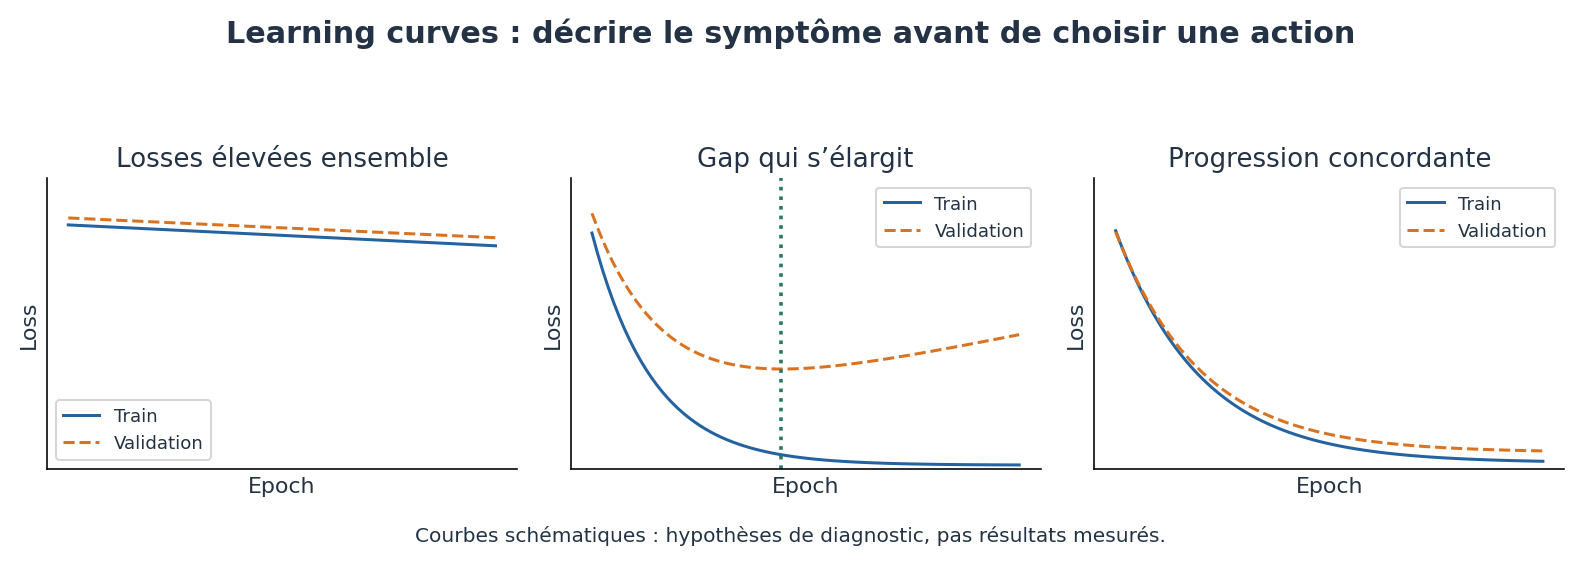

In [ ]:
def plot_digit_runs(runs):
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.3))
    for color, (name, (_, hist)) in zip(
        ["tab:blue", "tab:orange", "tab:green"], runs.items()
    ):
        ep = np.arange(1, len(hist["train_loss"]) + 1)
        for split, style in [("train", "-"), ("val", "--")]:
            axes[0].plot(
                ep,
                hist[f"{split}_loss"],
                style,
                color=color,
                label=f"{name} / {split}",
            )
            axes[1].plot(
                ep,
                hist[f"{split}_acc"],
                style,
                color=color,
                label=f"{name} / {split}",
            )
    axes[0].set(xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[1].set(xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.03))
    for ax in axes:
        ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


slow_run = fit_digits(lr=1e-5, hidden=32, epochs=12)
plot_digit_runs({"lr=1e-5": slow_run})

Exécutez maintenant l'essai proposé, après avoir écrit l'effet que vous en attendez. Si votre choix personnel diffère du réglage suggéré, conservez-le dans vos notes et indiquez pourquoi vous pensez qu'il répond au symptôme observé. Une modification n'est instructive que si l'on peut relier son effet à une hypothèse.

In [ ]:
learning_rate_correction = 0.004  # valeur suggérée ; une seule grandeur change
corrected_run = fit_digits(lr=learning_rate_correction, hidden=32, epochs=12)
plot_digit_runs(
    {"lr=1e-5": slow_run, f"lr={learning_rate_correction:g}": corrected_run}
)
rnn, selected_history = corrected_run

### 1.5 — Deuxième enquête : une training accuracy parfaite est-elle rassurante ?

Nous allons maintenant limiter le training set à 60 images, choisies de manière stratifiée à l'intérieur de la partition de training. Le validation set restera strictement inchangé. Avant de lancer le réseau, examinez cette restriction : combien d'écritures différentes d'un même chiffre sont encore représentées ? Une répartition presque égale entre les dix classes garantit-elle que la diversité des tracés a été conservée ? Le graphique donne les proportions des classes, puis quelques exemples du petit ensemble. Des proportions satisfaisantes peuvent dissimuler une pauvreté de formes ; un contrôle des effectifs ne remplace donc pas le regard porté sur les images.

Nous utilisons cette fois `hidden=64`, `lr=0.01`, `epochs=100`, avec le batch size conservé à 64. Le petit training set tient donc dans un seul batch. Il s'agit d'une nouvelle situation expérimentale, qui change plusieurs conditions pour faire apparaître un phénomène ; sa comparaison avec la première enquête ne doit pas servir à attribuer une cause unique à l'écart de performance. En revanche, la correction qui suivra conservera toutes ces conditions et ne modifiera que le nombre d'epochs. Comptez aussi les updates : cent epochs sur 60 exemples ne représentent pas le même nombre d'updates que cent epochs sur le training set complet.

**Avant le training, formulez une prédiction.** Une training loss très basse signifiera-t-elle que la reconnaissance s'est améliorée sur toutes les écritures, ou seulement que le réseau explique très bien les images qu'il a vues ? Quel mouvement de la validation loss vous ferait douter de l'utilité des dernières epochs ?

**Votre prédiction :** …

In [ ]:
small_train, _ = train_test_split(
    idx_train,
    train_size=60,
    stratify=digits.target[idx_train],
    random_state=42,
)
assert set(small_train).issubset(set(idx_train))
assert set(small_train).isdisjoint(set(idx_val))
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for name, indices, offset in [
    ("Training complet", idx_train, -0.24),
    ("Training réduit", small_train, 0),
    ("Validation", idx_val, 0.24),
]:
    counts = np.bincount(digits.target[indices], minlength=10)
    axes[0].bar(
        np.arange(10) + offset, counts / len(indices), width=0.24, label=name
    )
axes[0].set(xlabel="Classe", ylabel="Proportion", xticks=np.arange(10))
axes[0].legend(fontsize=8)
montage = np.concatenate([digits.images[i] for i in small_train[:8]], axis=1)
axes[1].imshow(montage, cmap="gray", vmin=0, vmax=16, aspect="equal")
axes[1].set_title("Huit images du petit training set")
axes[1].axis("off")
plt.tight_layout()
plt.show()
print(
    "Effectifs du petit training set par classe :",
    np.bincount(digits.target[small_train], minlength=10),
)
over_run = fit_digits(
    lr=0.01, hidden=64, epochs=100, train_indices=small_train
)
plot_digit_runs({"60 images, 100 epochs": over_run})

### 1.6 — Essayer une correction, puis vérifier ce qu’elle améliore

Cherchez sur la courbe l'endroit où la validation loss cesse durablement de suivre la training loss. Le modèle peut continuer à améliorer son ajustement aux exemples connus alors même que certaines erreurs de validation deviennent plus confiantes. C'est pourquoi une accuracy presque stable et une loss qui remonte ne se contredisent pas. La cross-entropy pénalise la confiance accordée à une mauvaise réponse ; elle peut donc révéler une dégradation que le seul nombre d'erreurs rend peu visible.

Le premier essai suggéré est de recommencer avec **25 epochs**, sans changer le modèle, les données, le learning rate ou la seed. Vous pouvez retenir une autre valeur entre **20 et 30** si votre plot la justifie. Cette intervention met à l'épreuve une hypothèse précise : les dernières updates améliorent surtout la mémorisation du training set. Avant de lancer la cellule, annoncez la direction attendue de chacune des deux losses. Ne demandez pas à la correction de résoudre tout le problème : arrêter plus tôt peut réduire une dégradation de validation sans compenser le manque de diversité des 60 exemples.

Le nombre d'epochs choisi à partir de la validation constitue une forme d'**early stopping**. Il est permis de consulter cette partition pour régler le training ; il faut ensuite reconnaître que sa performance a servi à la sélection. Un test set indépendant serait nécessaire pour estimer la généralisation après ces essais. Nous conservons ici cette frontière conceptuelle à chaque lecture des résultats.

**Votre choix, sa justification et le résultat attendu :** …

Le minimum indiqué dans le schéma des learning curves correspond au choix mathématique $e^\star\in\arg\min_e\mathcal L_{\mathrm{val}}(e)$. Votre essai à 25 epochs en est une approximation guidée par le plot observé, non un optimum imposé à toute exécution.

In [ ]:
epochs_correction = 25  # suggestion : essayer une valeur entre 20 et 30
early_run = fit_digits(
    lr=0.01, hidden=64, epochs=epochs_correction, train_indices=small_train
)
plot_digit_runs(
    {"100 epochs": over_run, f"{epochs_correction} epochs": early_run}
)
for label, (_, hist) in [
    ("Avant correction", over_run),
    ("Après correction", early_run),
]:
    gap = hist["val_loss"][-1] - hist["train_loss"][-1]
    print(
        f'{label} | loss train={hist["train_loss"][-1]:.4f}'
        f' | loss val={hist["val_loss"][-1]:.4f} | gap={gap:.4f}'
    )

# Regarder des erreurs, en conservant le modèle de 100 epochs pour ce diagnostic.
over_model = over_run[0]
over_model.eval()
wrong = []
with torch.no_grad():
    for i in idx_val:
        x = sequences[i][None]
        length = torch.tensor([x.shape[1]])
        probabilities = over_model(x, length).softmax(-1)[0]
        prediction = int(probabilities.argmax())
        if prediction != int(digits.target[i]):
            wrong.append((i, prediction, float(probabilities[prediction])))
        if len(wrong) == 4:
            break
if wrong:
    fig, axes = plt.subplots(1, len(wrong), figsize=(9, 2.5), squeeze=False)
    for ax, (i, prediction, confidence) in zip(axes[0], wrong):
        ax.imshow(digits.images[i], cmap="gray", vmin=0, vmax=16)
        ax.set_title(
            f"Label {digits.target[i]} → prédiction {prediction}\np={confidence:.2f}"
        )
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Aucune erreur de validation pour cette exécution.")

### 1.7 — Construire un diagnostic qui résiste à la discussion

**Q2.** Complétez le carnet d'essais ci-dessous, puis expliquez ce qui distingue les deux difficultés rencontrées. Pour la première, quelle observation permet d'incriminer le learning rate plutôt que la seule capacité du réseau ? Pour la seconde, pourquoi une training accuracy de 100 % ne prouve-t-elle pas une bonne généralisation ? Appuyez-vous sur les losses, sur l'accuracy et sur une erreur visualisée. Une correction peut-elle être utile tout en laissant un gap important ? Terminez en expliquant pourquoi la longueur variable ne change pas le nombre de paramètres, et pourquoi ces chiffres courts ne prouvent pas une mémoire de cent pas.

| Essai | Symptôme observé | Hypothèse | Unique modification testée | Résultat et conclusion |
|---|---|---|---|---|
| Learning rate très faible → correction | … | … | … | … |
| Petit training set, 100 epochs → correction | … | … | … | … |

**Votre réponse à Q2 :** …

## Exercice 2 — Suivre le retour du gradient
### La question, les données et l’instrument de mesure

**But de l'expérience.** Le réseau vient de former une décision en allant du début de la suite vers sa fin. L'apprentissage parcourt le graphe en sens inverse : il cherche comment modifier les opérations passées pour réduire l'erreur présente. Nous allons rendre ce trajet visible. Une première expérience, volontairement dépouillée, isolera l'effet de la répétition d'une même transformation. Une seconde retrouvera le classifieur appris et mesurera la distribution de son signal de correction.

**Données.** Le système contrôlé reçoit une suite de $T=80$ entrées nulles et part d'un état nul. Toutes ses conditions sont connues ; il n'y a donc pas de séparation statistique à effectuer pour cette mesure de dérivée. Pour l'observation sur données, nous prenons un chiffre dans la partition de validation déjà constituée. Son utilisation sera diagnostique : la mesure du gradient ne sera suivie d'aucune update des poids du classifieur.

**Modèle et description formelle.** Considérons le RNN scalaire
$$h_t=\tanh(a h_{t-1}),\qquad h_0=0,\qquad S=h_T.$$
La quantité $S$ est une sonde de sensibilité. Sur cette trajectoire, tous les états valent zéro, mais les dérivées satisfont
$$\frac{\partial h_t}{\partial h_{t-1}}=a(1-h_t^2),\qquad
\frac{\partial S}{\partial h_t}=\prod_{u=t+1}^{T}a(1-h_u^2).$$
Cette expression donne une prédiction théorique à confronter au calcul automatique. Dans le RNN vectoriel de l'exercice 1, chaque facteur devient une Jacobienne $J_t=\operatorname{diag}(1-h_t^2)W_h$ ; le gradient de la loss traverse le produit de leurs transposées. Nous examinerons trois gains, $a=0{,}7$, $1$ et $1{,}3$, pour observer l'atténuation, la conservation et l'amplification du signal le long de la trajectoire contrôlée.

**Choisir les mesures.** Une accuracy de classification ne renseignerait pas directement sur ce trajet. Nous mesurons donc $g_t=|\partial S/\partial h_t|$ pour la sonde et $g_t=\|\partial\mathcal L_{\mathrm{CE}}/\partial h_t\|_2$ pour le chiffre. Afin de résumer où se répartit le signal, nous calculons
$$p_t=\frac{g_t}{\sum_sg_s},\qquad
K_{90}=\min\left\{K:\sum_{t=T-K+1}^{T}p_t\geq0{,}9\right\}.$$
Les normes brutes indiquent l'échelle ; les masses normalisées décrivent la répartition. Ces grandeurs dépendent du modèle, de la loss, des unités et de l'exemple. Elles mesurent une sensibilité locale, non une information en bits ou une capacité générale de mémoire.

**Optimisation et hyperparamètres.** Pour observer concrètement l'effet du clipping sur une update, nous utiliserons ensuite $\mathcal L_{\mathrm{sonde}}=\tfrac12(h_T-1)^2$ en rendant l'état initial $p=h_0$ ajustable. Nous comparerons une unique update SGD avec et sans clipping. Le gain reste fixé : cette expérience porte sur le déplacement de $p$, et sa loss n'est pas une métrique de généralisation.

| Choix | Valeur | Fonction |
|---|---:|---|
| Longueur contrôlée $T$ | 80 | Distance de transport du gradient |
| Gains $a$ | 0,7 ; 1 ; 1,3 | Amplitude de la dérivée locale à l'origine |
| Précision numérique de la sonde | `float64` | Observer une grande plage de normes |
| SGD : learning rate ; updates | $10^{-3}$ ; 1 | Isoler l'effet sur le déplacement du paramètre |
| Seuil de clipping | 1 | Borner la norme du gradient de $p$ |
| Coupure du graphe du classifieur | 3 derniers pas | Comparer trajet complet et trajet tronqué |

Cette expérience réclame une attention particulière : la valeur d'un état et sa sensibilité sont deux objets distincts. Nous allons les représenter séparément pour éviter de prendre la tranquillité apparente du premier pour une preuve de stabilité du second.

**Lire le schéma.** La chaîne bleue transporte les états vers la décision. Le trajet orange transporte une sensibilité vers les états antérieurs. Une flèche du backward représente une multiplication par une Jacobienne transposée ; plusieurs transitions composent donc plusieurs facteurs. C'est cette répétition, et non la seule taille des états, que la sonde va éprouver.

$$\nabla_{h_t}\mathcal L=J_{t+1}^{\mathsf T}\cdots J_T^{\mathsf T}\nabla_{h_T}\mathcal L.$$

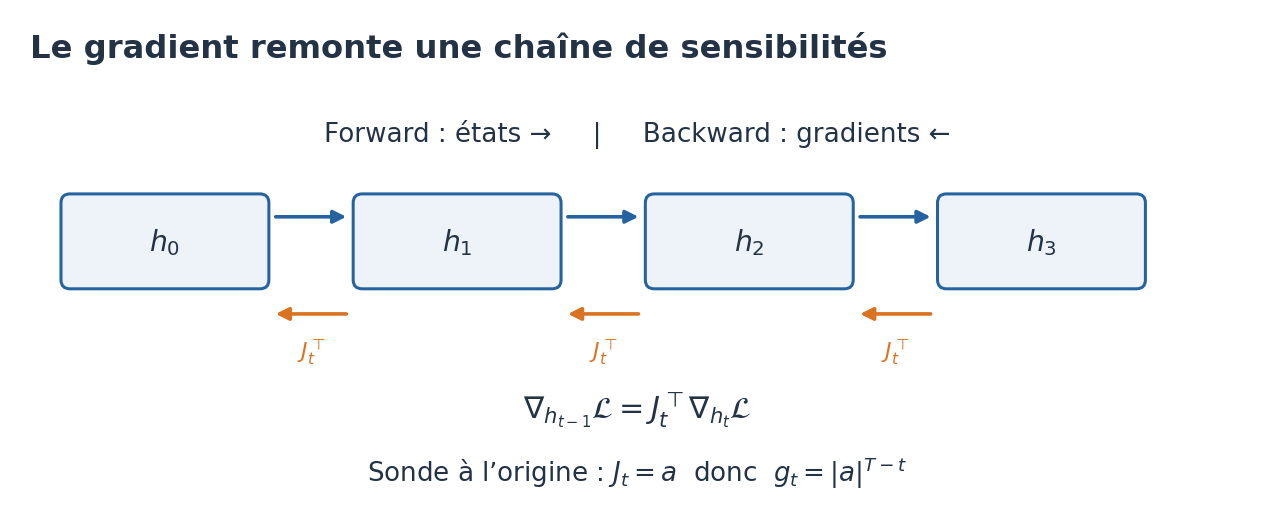

### 2.1 — Visualiser les conditions et retrouver les partitions

La première figure montre la suite d'entrée et la trajectoire d'état attendue à l'origine. La seconde montre le chiffre de validation qui servira à l'analyse du classifieur. Vérifiez sa longueur : elle déterminera le nombre de points du profil réel. Notez le contraste entre les 80 transitions du système contrôlé et les quelques colonnes du dessin ; ces deux expériences ne répondent pas à la même question.

In [ ]:
PROBE_T = 80
diagnostic_index = int(next(i for i in idx_val if len(sequences[i]) >= 5))
fig, axes = plt.subplots(1, 2, figsize=(9, 2.6))
axes[0].plot(np.arange(PROBE_T + 1), np.zeros(PROBE_T + 1))
axes[0].set(
    xlabel="Pas t",
    ylabel="Valeur",
    title="Entrées et états à l’origine : zéro",
)
axes[1].imshow(sequences[diagnostic_index].T, cmap="gray", vmin=0, vmax=1)
axes[1].set_title(
    f"Validation : chiffre {digits.target[diagnostic_index]}, longueur {len(sequences[diagnostic_index])}"
)
axes[1].grid(False)
plt.tight_layout()
plt.show()
assert diagnostic_index in set(idx_val)

### 2.2 — Construire la sonde et contrôler ses dimensions

**C2a :** traduisez un pas de la récurrence scalaire. Chaque état est un tenseur de forme `(1,)`. Conserver les états permet d'examiner séparément leurs gradients ; `retain_grad()` demande à PyTorch de ne pas effacer ces dérivées intermédiaires après la backpropagation. La sonde finale est scalaire. La fonction doit retourner un tableau de $T+1$ normes, incluant l'état initial.

Commencez par annoncer le comportement attendu sur un axe logarithmique : quelle forme produira la répétition d'un facteur constant ? Confrontez ensuite les trois profils à la formule analytique. La vérification ne porte pas seulement sur le nombre de valeurs, mais aussi sur leur accord avec une prédiction indépendante du code de différentiation.

In [ ]:
def gradient_probe(gain, T=80):
    hidden = torch.zeros(1, dtype=torch.float64, requires_grad=True)
    states = [hidden]

    for step in range(T):
        # C2a : une transition du RNN scalaire.
        raise NotImplementedError("C2a : calculer un pas de la récurrence")
        hidden.retain_grad()
        states.append(hidden)

    final_probe = states[-1].sum()
    final_probe.backward()

    gradient_norms = []
    for state in states:
        gradient_norm = state.grad.abs().item()
        gradient_norms.append(gradient_norm)

    return np.array(gradient_norms)


for gain in [0.7, 1.0, 1.3]:
    measured_gradients = gradient_probe(gain, T=PROBE_T)
    assert measured_gradients.shape == (PROBE_T + 1,)

    distance_to_end = np.arange(PROBE_T + 1)[::-1]
    theoretical_gradients = gain**distance_to_end

    assert np.allclose(
        measured_gradients,
        theoretical_gradients,
        rtol=1e-8,
        atol=1e-14,
    )
    plt.semilogy(distance_to_end, measured_gradients, label=f"a = {gain}")

plt.xlabel("Distance au dernier état T−t")
plt.ylabel("|∂S/∂h_t|")
plt.legend()
plt.tight_layout()
plt.show()

### 2.3 — Construire une update et mesurer l’effet du clipping

La cellule suivante reproduit les étapes d'une training loop, mais s'arrête après une seule update afin de rendre le mécanisme lisible. Deux paramètres partent exactement de la même valeur. Pour le premier, le gradient est utilisé tel quel ; pour le second, sa norme est bornée. **C2b :** placez l'appel de clipping au point indiqué, après le calcul de la dérivée et avant le déplacement effectué par SGD.

Nous relevons la loss avant et après, la norme du gradient avant et après clipping, et le déplacement du paramètre. Ces mesures doivent être lues ensemble : une diminution immédiate de la loss ne suffit pas à établir qu'un pas gigantesque est une bonne stratégie de training. Sur cette récurrence, la saturation de `tanh` peut précisément masquer la violence du déplacement.

**Lire le schéma.** À gauche, le clipping ramène un vecteur trop grand dans une boule de norme autorisée, en gardant sa direction. À droite, detach conserve la valeur transmise, mais supprime la dépendance par laquelle une dérivée pouvait remonter. Les deux opérations interviennent donc sur des objets différents.

$$g_{\mathrm{clip}}=g\min(1,\tau/\lVert g\rVert_2),\qquad \operatorname{val}(\operatorname{detach}(h))=\operatorname{val}(h).$$

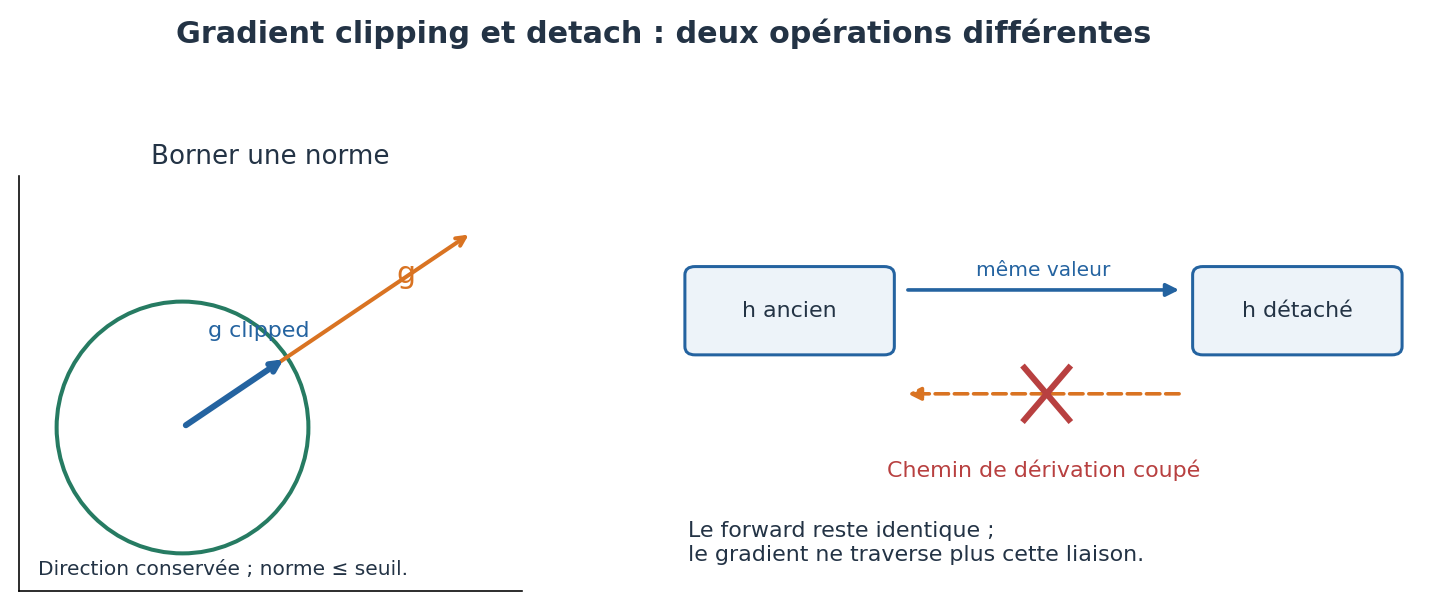

In [ ]:
def scalar_objective(p, gain=1.3, steps=80):
    h = p
    for _ in range(steps):
        h = torch.tanh(gain * h)
    return 0.5 * (h - 1).square().sum()


for use_clip in [False, True]:
    p = nn.Parameter(torch.zeros(1, dtype=torch.float64))
    optimizer = torch.optim.SGD([p], lr=1e-3)
    optimizer.zero_grad(set_to_none=True)
    loss = scalar_objective(p)
    assert loss.ndim == 0
    loss.backward()
    norm_before = p.grad.norm().item()
    if use_clip:
        raise NotImplementedError("C2b : borner la norme du gradient")
    norm_after = p.grad.norm().item()
    optimizer.step()
    with torch.no_grad():
        loss_after = scalar_objective(p).item()
    print(
        f"Clipping={use_clip} | loss {loss.item():.4f} → {loss_after:.4f}"
        f" | norme {norm_before:.3g} → {norm_after:.3g} | déplacement p={p.item():.3g}"
    )
    if use_clip:
        assert norm_after <= 1.000001

### 2.4 — Choisir les conditions d’observation et retrouver le réseau appris

Le gain $a$ et la distance $T-t$ sont les deux paramètres du premier examen. Comparez l'effet de leur variation à celui du seuil de clipping : le gain intervient dans le transport de la dérivée, alors que le clipping intervient une fois les dérivées calculées. Le suivi de cette expérience est donc celui des normes et de l'update. Pour le classifieur, les learning curves train/validation de l'exercice 1 fournissent le contexte dans lequel le diagnostic doit être interprété.

Revenons au chiffre réservé. Nous calculons une fois son gradient complet, puis une fois son gradient après une coupure du graphe avant les trois derniers pas. `detach()` conserve la valeur de l'état transmis, mais coupe sa relation de dérivation avec le passé. Aucune update des poids n'est effectuée. Le test demande donc que les logits soient identiques, tandis que les gradients des états antérieurs à la coupure disparaissent. Un gradient absent est représenté par zéro ; pour le tracé logarithmique seulement, nous l'affichons à $10^{-16}$.

**Lire le schéma.** Dans cet exemple construit pour la lecture, les deux derniers pas portent 0,30 et 0,60 de la masse totale ; ils suffisent donc à atteindre 90 %. Le même profil normalisé pourrait provenir de gradients bruts mille fois plus petits. Conservez les deux représentations pour ne pas effacer cette différence d'échelle.

$$p_t=\frac{g_t}{\sum_sg_s},\qquad K_{90}=\min\left\{K:\sum_{t=T-K+1}^T p_t\geq0.9\right\}.$$

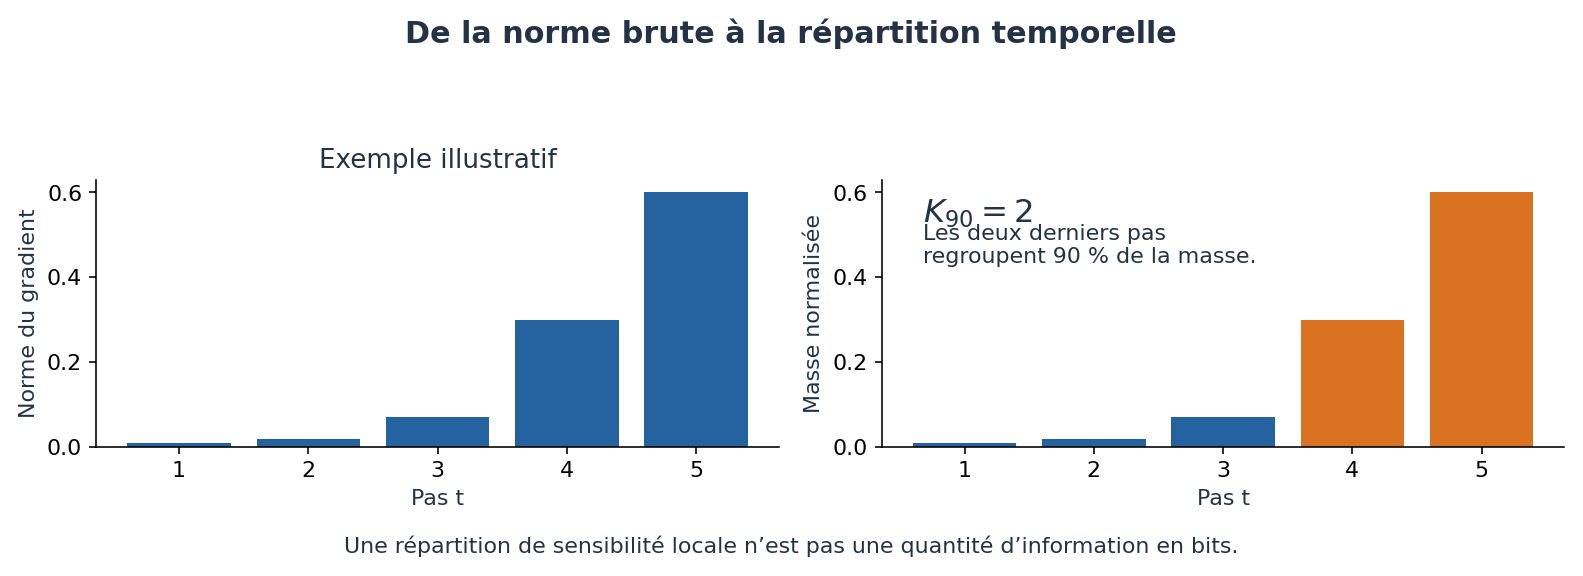

In [ ]:
example_index = diagnostic_index
rnn.eval()

# Un seul exemple : ajouter explicitement l'axe du batch.
example_sequence = sequences[example_index].unsqueeze(0)
example_length = torch.tensor([example_sequence.shape[1]])
example_label = torch.tensor([int(digits.target[example_index])])


def real_profile(truncate=None):
    rnn.zero_grad(set_to_none=True)

    logits, states = rnn(
        example_sequence,
        example_length,
        trace=True,
        truncate=truncate,
    )
    classification_loss = F.cross_entropy(logits, example_label)
    classification_loss.backward()

    gradient_norms = []
    for state in states:
        if state.grad is None:
            # Aucun chemin dans le graphe ne rejoint cet état.
            gradient_norm = 0.0
        else:
            gradient_norm = state.grad.norm().item()
        gradient_norms.append(gradient_norm)

    return logits.detach(), np.array(gradient_norms)


logits_full, g_full = real_profile()
logits_cut, g_cut = real_profile(truncate=3)

assert torch.allclose(logits_full, logits_cut)
assert np.all(g_cut[:-3] == 0)
assert g_full.sum() > 0

mass = g_full / g_full.sum()
cumulative_from_end = np.cumsum(mass[::-1])
k90 = int(np.searchsorted(cumulative_from_end, 0.9) + 1)

print(
    f"Exemple {example_index}, longueur {len(g_full)}"
    f" ; K90 = {k90} pas"
    f" ; somme des normes = {g_full.sum():.4g}"
)

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
profiles = [(g_full, "Complète"), (g_cut, "Coupée, K=3")]

for gradient_norms, label in profiles:
    steps = np.arange(1, len(gradient_norms) + 1)
    values_for_plot = np.maximum(gradient_norms, 1e-16)
    axes[0].semilogy(steps, values_for_plot, "o-", label=label)

axes[0].set(
    xlabel="Pas t",
    ylabel="Norme du gradient",
    title="Zéros affichés à 1e−16",
)
axes[0].legend()

axes[1].bar(np.arange(1, len(mass) + 1), mass)
axes[1].set(xlabel="Pas t", ylabel="Masse normalisée p_t")

plt.tight_layout()
plt.show()

### 2.5 — Distinguer mémoire, sensibilité et chemin de calcul

**Q3.** Pour les trois gains, estimez le rapport entre le gradient à l'origine et celui du dernier état. Pourquoi la borne $|h_t|\leq1$ ne borne-t-elle pas ce rapport ? Décrivez l'effet du clipping sur le déplacement de $p$ et précisez ce qu'il ne peut pas restaurer.

**Q4.** Comment la coupure peut-elle préserver la prédiction et modifier la backpropagation ? Les poids du RNN étant partagés, cessent-ils entièrement de recevoir un gradient lorsque le passé est détaché ?

**Q5.** Interprétez le $K_{90}$ mesuré en citant l'exemple, la loss et le modèle auxquels il se rapporte. Pourquoi faudrait-il conserver les normes brutes et observer plusieurs exemples avant d'avancer une conclusion sur la transmission du signal ?

**Vos réponses à Q3–Q5 :** …

**Au terme de la première séance.** Formulez la relation entre les trois observations : le réseau accepte plusieurs longueurs, ses poids sont partagés, et le gradient doit traverser les transformations successives. Enregistrez votre notebook avec les figures qui étayent votre explication.

## Exercice 3 — Produire une suite et apprendre où regarder
### La question, les données et l’instrument de mesure

**But de l'expérience.** Nous demandons maintenant au réseau de produire une suite entière. La lecture de la source devient le travail d'un encoder ; la production, celui d'un decoder. Nous étudierons d'abord le passage de l'un à l'autre par un état final, puis nous donnerons au decoder la possibilité de consulter les états intermédiaires de l'encoder. Le but est de construire nous-mêmes cette consultation, de suivre ce qu'elle apprend à privilégier et de comprendre le chemin supplémentaire qu'elle ouvre au gradient.

**Données.** Chaque source est une suite de 3 à 9 chiffres tirés uniformément. Sa cible est la suite renversée, suivie d'un symbole de fin : `2 5 1 → 1 5 2 EOS`. Nous engendrons 1 600 paires pour apprendre et 240 paires distinctes pour valider. Cette tâche algorithmique possède une réponse et un alignement attendus parfaitement connus. Elle permet donc de poser une question nette : le modèle a-t-il appris à retrouver, au bon moment, le symbole situé à la bonne position ? Les identifiants `PAD=0`, `BOS=1`, `EOS=2` sont réservés ; les chiffres 0 à 9 portent les identifiants 3 à 12.

**Modèle.** Un embedding appris associe à chaque identifiant un vecteur $v\in\mathbb R^D$. L'encoder et le decoder sont des GRU de hidden size $H$. Pour rendre précise la récurrence utilisée par PyTorch, une cellule GRU peut s'écrire
$$r=\sigma(W_{ir}v+b_{ir}+W_{hr}h+b_{hr}),\quad
z=\sigma(W_{iz}v+b_{iz}+W_{hz}h+b_{hz}),$$
$$n=\tanh\!\left(W_{in}v+b_{in}+r\odot(W_{hn}h+b_{hn})\right),\qquad
h'=(1-z)\odot n+z\odot h.$$
Les portes $r$ et $z$ modulent la transformation de l'état ; $\odot$ désigne un produit composante par composante. Nous utilisons cette cellule fournie par PyTorch pour concentrer notre construction sur l'enchaînement encoder–decoder et sur l'attention.

Les états encoder vérifient $e_s=\operatorname{GRU}_{enc}(v(x_s),e_{s-1})$, avec $e_0=0$. Le decoder commence à $q_0=e_\ell$, puis calcule $q_t=\operatorname{GRU}_{dec}(v(u_t),q_{t-1})$. Avec attention,
$$a_{t,s}=q_t^TW_ae_s,\qquad
\alpha_{t,s}=\frac{\exp(a_{t,s})}{\sum_{j\leq\ell}\exp(a_{t,j})},\qquad
c_t=\sum_{s=1}^{\ell}\alpha_{t,s}e_s.$$
La prédiction est $o_t=W_o[q_t;c_t]+b_o$, suivie d'un softmax sur les 13 symboles. Dans la variante sans attention, $c_t=0$ : l'information source atteint le decoder par son état initial. Pendant le training, $u_1=\mathrm{BOS}$ et $u_t=y_{t-1}$ ; c'est le *teacher forcing*. Pendant la génération, la prédiction précédente remplace $y_{t-1}$. Le décodage s'arrête à EOS, avec une longueur maximale de sécurité.

**Loss d'optimisation et validation.** Nous optimisons la cross-entropy moyenne sur les positions cibles valides, EOS compris :
$$\mathcal L=-\frac1{N_{tok}}\sum_{b,t:\,y_{b,t}\ne\mathrm{PAD}}
\log p_\theta(y_{b,t}\mid X_b,y_{b,<t}).$$
La normalisation utilise le nombre de tokens valides du batch, puis les métriques d'ensemble sont agrégées par ce même nombre. Une séquence longue contribue ainsi par davantage de prédictions qu'une séquence courte. Le padding doit être ignoré : sinon, la quantité de remplissage du batch modifierait artificiellement le problème appris.

Sur la validation, nous suivons cette même loss en teacher forcing afin de la comparer à la training loss. Nous mesurons aussi, en **génération autonome**, la token accuracy et la proportion de suites entièrement correctes, EOS inclus. Le modèle n'a alors accès à aucune cible. Une bonne prédiction avec le passé correct fourni et une bonne génération avec son propre passé sont deux épreuves différentes ; leurs métriques doivent rester explicitement distinguées.

| Hyperparamètre | Valeur | Rôle |
|---|---:|---|
| Longueurs sources | 3 à 9 | Domaine de l'expérience |
| Embedding $D$ ; état $H$ | 24 ; 48 | Dimensions des représentations |
| Batch size ; epochs | 64 ; 16 | Budget de training |
| Optimizer ; learning rate | Adam ; 0,003 | Update des paramètres |
| Seuil de clipping | 1 | Borne de norme des gradients |
| Teacher forcing pendant le training | 100 % | Historique cible décalé d'un pas |
| Limite de génération | 14 tokens | Garde-fou si EOS n'est pas produit |
| Seeds données train/validation ; modèle | 10 / 20 ; 123 | Reproduction de la comparaison |

Les deux architectures seront soumises au même budget, aux mêmes paires et au même ordre de batches. L'attention ajoute une matrice apprise $W_a$ : cette différence de capacité fait partie de la comparaison et doit rester présente à l'esprit lorsque l'on interprète les résultats.

**Lire le schéma.** La première récurrence lit la source ; son dernier état valide initialise la seconde. Les états du decoder produisent les tokens de la target, puis EOS. Les tokens qui alimentent ce decoder sont détaillés dans le schéma du teacher forcing. L'attention donnera ensuite un accès supplémentaire aux états intermédiaires de l'encoder.

$$e_s=\operatorname{GRU}_{enc}(v(x_s),e_{s-1}),\qquad q_0=e_\ell,\qquad q_t=\operatorname{GRU}_{dec}(v(u_t),q_{t-1}).$$

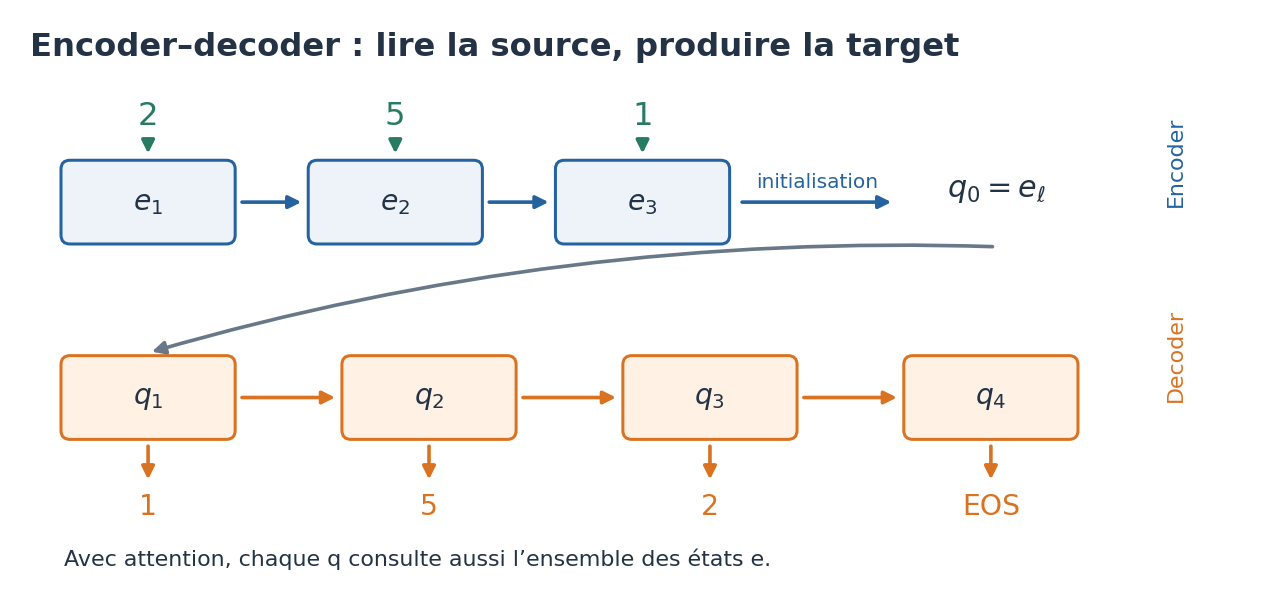

**Lire le schéma.** La branche haute conserve une part de l'état précédent ; la branche basse apporte un candidat. La porte z règle leur combinaison composante par composante. La flèche pointillée rappelle que le candidat dépend aussi de l'état précédent, modulé par la porte r : il n'est pas calculé à partir du seul token courant.

$$h_t=(1-z_t)\odot n_t+z_t\odot h_{t-1}.$$

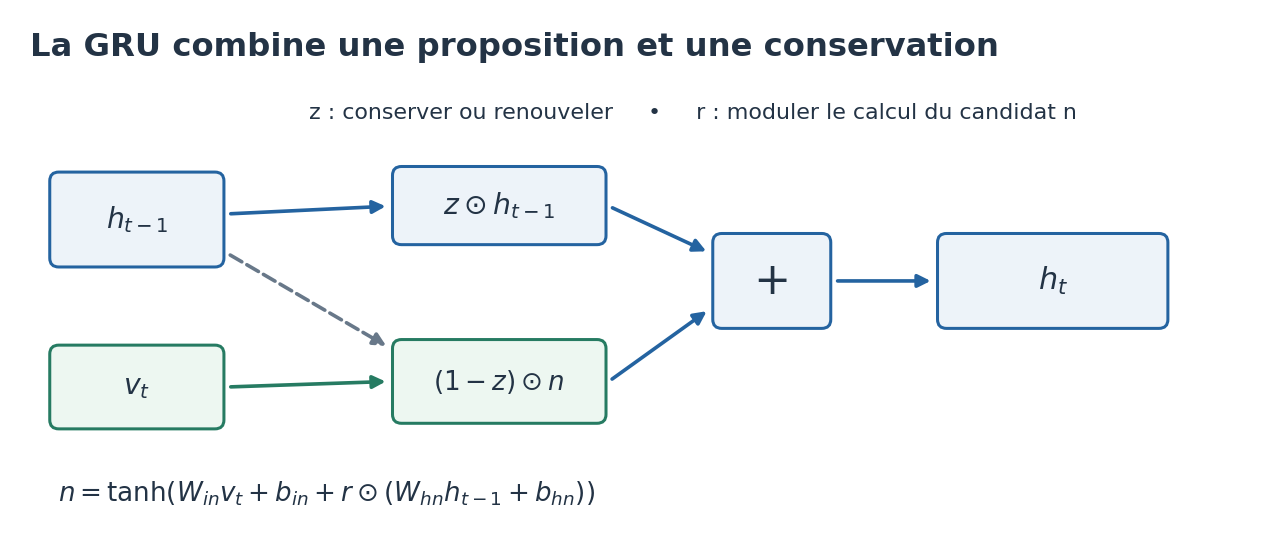

### 3.1 — Visualiser les paires et préparer les séquences de longueur variable

Lisez quelques paires avant de vous occuper du réseau. Distinguez soigneusement le chiffre dessiné dans une liste et l'identifiant qui le représente dans un tenseur. **C3 :** construisez l'entrée du decoder en plaçant BOS devant la cible privée de son dernier élément. À chaque position, le modèle doit recevoir le symbole précédent, jamais celui qu'il est chargé de prédire au même pas. Ce décalage exprime la causalité de la génération.

La cellule contrôle que les sources des deux partitions sont disjointes. Elle affiche ensuite quelques transformations attendues et les distributions de longueurs. Chaque batch possède ses propres maxima : la longueur source, la longueur cible et la dimension de représentation sont trois notions distinctes. Le padding complète les tableaux ; EOS appartient au contenu à prédire et apprend au modèle à terminer sa réponse.

Interrogez aussi la façon dont ce dataset a été construit. Les chiffres sont tirés uniformément, mais une source longue contient davantage de décisions à réussir pour être entièrement correcte. Une baisse de sequence accuracy avec la longueur ne signifie donc pas, à elle seule, que le modèle a cessé de mémoriser le début ; elle peut aussi résulter de l'accumulation de petites erreurs. Les répétitions de chiffres rendent par ailleurs certains alignements moins faciles à interpréter. Comparez les distributions de longueurs entre training et validation, puis gardez ces deux difficultés à l'esprit lorsque vous lirez les métriques. Enfin, des sources distinctes empêchent une copie exacte des exemples, mais restent des exemples de la même règle d'inversion : nous évaluons ici la généralisation à de nouvelles suites dans ce domaine défini.

**Lire le schéma.** Lisez chaque colonne verticalement : l'entrée et la target du même pas ne sont pas le même événement. Les flèches vertes décalent le token correct vers le pas suivant. Pendant la génération autonome, ce sont les prédictions déjà produites qui occupent ces places ; une erreur peut ainsi devenir une entrée future.

$$u_1=\mathrm{BOS},\qquad u_t=y_{t-1}\ \text{en teacher forcing},\qquad u_t=\hat y_{t-1}\ \text{en génération}.$$

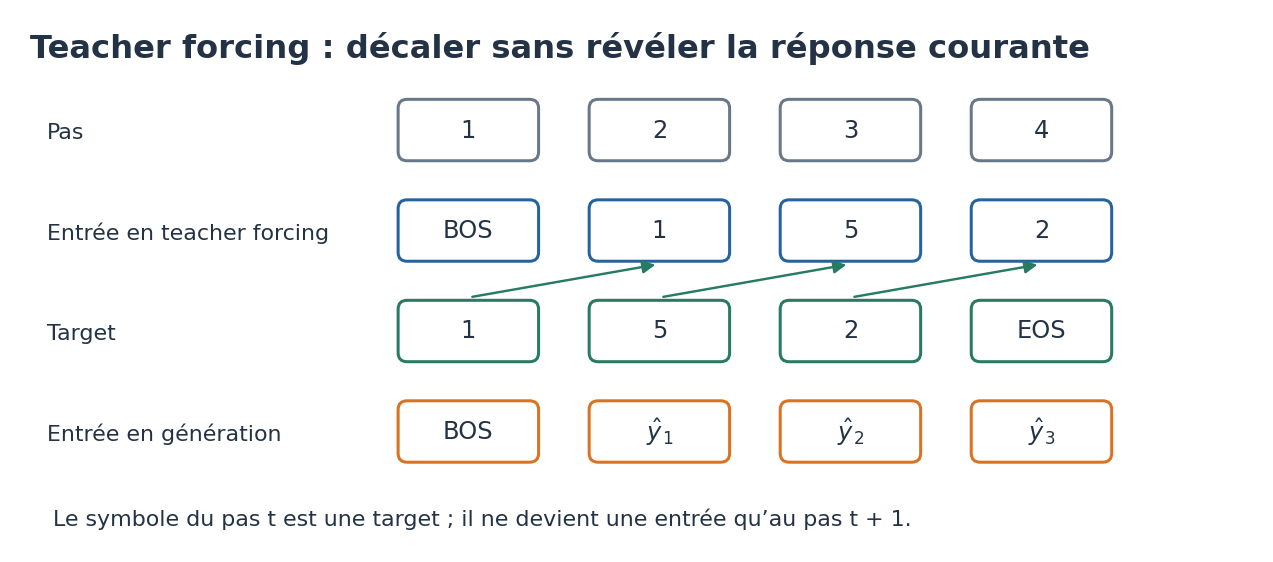

**Lire le schéma.** Suivez séparément les deux lignes. La source comporte trois positions à consulter ; la target comporte quatre décisions à évaluer, car EOS compte. Masquer la target dans la loss ne modifie pas la distribution d'attention sur la source.

$$\alpha_{t,s}=0\ \text{si la source }s\text{ est PAD},\qquad \mathcal L=\frac{1}{N_{\mathrm{tok}}}\sum_{b,t:y_{b,t}\ne\mathrm{PAD}}\mathcal L_{b,t}.$$

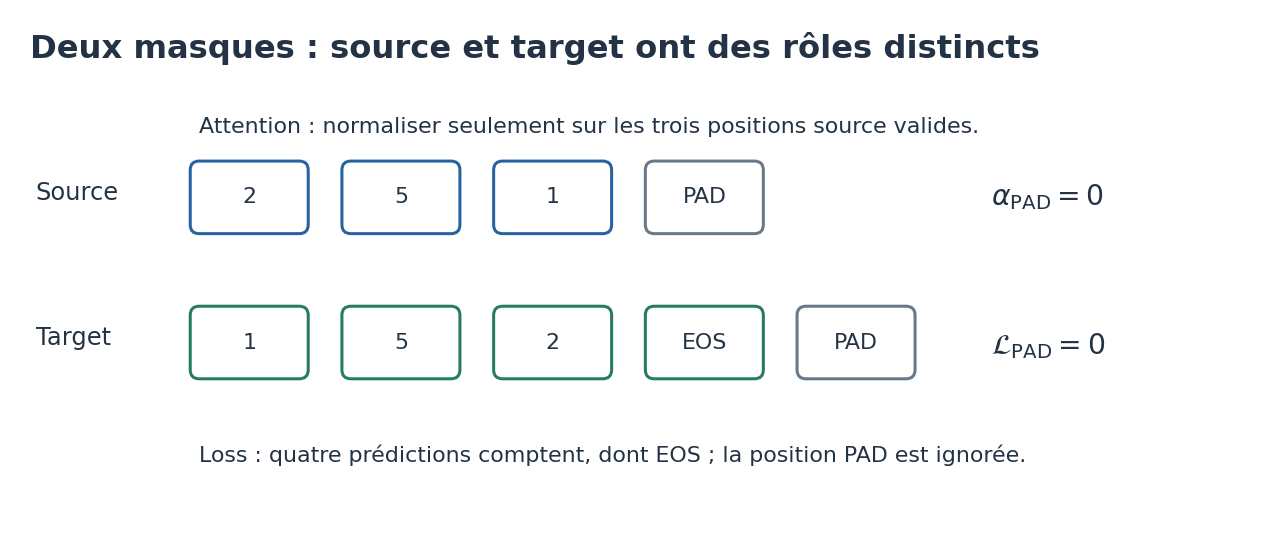

In [ ]:
# Les identifiants spéciaux ne représentent pas des chiffres.
PAD = 0
BOS = 1
EOS = 2
VOCAB = 13
seed_all(123)


def make_pairs(n, lo, hi, seed, forbidden=()):
    rng = np.random.default_rng(seed)
    used_sources = set(forbidden)
    pairs = []

    while len(pairs) < n:
        source_length = int(rng.integers(lo, hi + 1))
        token_ids = rng.integers(3, VOCAB, size=source_length)
        source_key = tuple(token_ids.tolist())

        if source_key in used_sources:
            continue
        used_sources.add(source_key)

        reversed_source = source_key[::-1]
        target_key = reversed_source + (EOS,)

        source_tensor = torch.tensor(source_key)
        target_tensor = torch.tensor(target_key)
        pairs.append((source_tensor, target_tensor))

    return pairs


train_pairs = make_pairs(1600, 3, 9, seed=10)
seen_sources = set()
for source, target_example in train_pairs:
    seen_sources.add(tuple(source.tolist()))

val_pairs = make_pairs(240, 3, 9, seed=20, forbidden=seen_sources)
for source, target_example in val_pairs:
    assert tuple(source.tolist()) not in seen_sources

In [ ]:
def seq_collate(items):
    source_sequences, target_sequences = zip(*items)

    source_lengths = []
    for source in source_sequences:
        source_lengths.append(len(source))

    padded_sources = pad_sequence(
        source_sequences, batch_first=True, padding_value=PAD
    )
    padded_targets = pad_sequence(
        target_sequences, batch_first=True, padding_value=PAD
    )
    lengths = torch.tensor(source_lengths)

    return padded_sources, lengths, padded_targets


def seq_loader(pairs, shuffle=False):
    random_generator = torch.Generator().manual_seed(123)
    return DataLoader(
        pairs,
        batch_size=64,
        shuffle=shuffle,
        collate_fn=seq_collate,
        generator=random_generator,
    )

In [ ]:
def shifted_targets(target):
    batch_size = target.shape[0]
    start = target.new_full((batch_size, 1), BOS)
    previous_targets = target[:, :-1]

    # C3 : BOS est suivi de la target décalée d'un pas.
    raise NotImplementedError("C3 : concaténer BOS et les tokens précédents")
    return dec_in


src, src_len, target = next(iter(seq_loader(train_pairs)))
dec_in = shifted_targets(target)

assert torch.all(dec_in[:, 0] == BOS)
assert torch.equal(dec_in[:, 1:], target[:, :-1])

print("Source, longueurs, target :", src.shape, src_len.shape, target.shape)
print("Identifiants première source :", src[0].tolist())
print("Entrée decoder :", dec_in[0].tolist())
print("Target :", target[0].tolist())

In [ ]:
def token_name(t):
    return {PAD: "PAD", BOS: "BOS", EOS: "EOS"}.get(int(t), str(int(t) - 3))


for source, target_example in train_pairs[:4]:
    print(
        " ".join(map(token_name, source)),
        "→",
        " ".join(map(token_name, target_example)),
    )
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
for ax, pairs, title in zip(
    axes, [train_pairs, val_pairs], ["Training", "Validation"]
):
    ax.hist([len(x) for x, _ in pairs], bins=np.arange(2.5, 10.5), rwidth=0.8)
    ax.set(xlabel="Longueur source", ylabel="Effectif", title=title)
plt.tight_layout()
plt.show()

**Q6.** Pour une source de longueur 5, donnez la longueur cible et écrivez symboliquement l'entrée du decoder. Expliquez pourquoi une mesure en teacher forcing ne suffit pas à valider la génération autonome.

**Votre réponse à Q6 :** …

### 3.2 — Construire l’attention et vérifier la géométrie des tenseurs

Une fonction d'attention accomplit trois opérations : comparer la requête à chacune des clés, transformer les scores en poids normalisés, puis former une somme pondérée des valeurs. Ici, les états encoder jouent à la fois le rôle des clés et celui des valeurs. **C4 :** écrivez successivement les scores, les poids et le contexte. Le produit matriciel par batch `torch.bmm` sera votre outil ; `unsqueeze` et `squeeze` vous permettront d'exprimer un vecteur comme une matrice à une seule ligne ou colonne.

Le masque s'applique **avant** le softmax : les scores des positions absentes valent $-\infty$, de sorte que leur poids soit nul. Le dénominateur ne doit compter que les positions observées. Une somme égale à un ne suffit donc pas à certifier une attention correcte ; nous vérifierons aussi que modifier les valeurs de padding ne modifie pas le contexte.

| Objet | Forme |
|---|---|
| Requête decoder $q_t$ | `(B, H)` |
| Mémoire encoder $E$ | `(B, S, H)` |
| Masque source | `(B, S)` |
| Scores et poids | `(B, S)` |
| Contexte $c_t$ | `(B, H)` |

La projection `self.proj(q)` représente $q^TW_a$ dans la convention ligne. `nn.Linear` conserve sa propre matrice sous la convention transposée ; l'important est de vérifier la transformation réalisée, non de déduire son orientation du seul nom d'une variable.

Dans le code, `score_columns` garde provisoirement un axe de taille 1 ; `squeeze(-1)` donne ensuite les scores (B,S). De même, `context_rows` a la forme `(B,1,H)` avant `squeeze(1)`. Ces étapes séparées vous permettent de vérifier chaque produit matriciel sans combiner plusieurs opérations dans une seule ligne.

**Lire le schéma.** Le circuit se lit en trois temps : comparer, normaliser, combiner. Les formes inscrites dans les boîtes correspondent aux variables intermédiaires de la cellule Python. Dans l'exemple numérique, masquer la dernière position conduit aux poids 1/3, 2/3 et 0 ; le contexte est alors une combinaison de deux valeurs seulement.

$$a_s=q^{\mathsf T}W_ae_s,\qquad\alpha=\operatorname{softmax}(\operatorname{mask}(a)),\qquad c=\sum_s\alpha_s e_s.$$

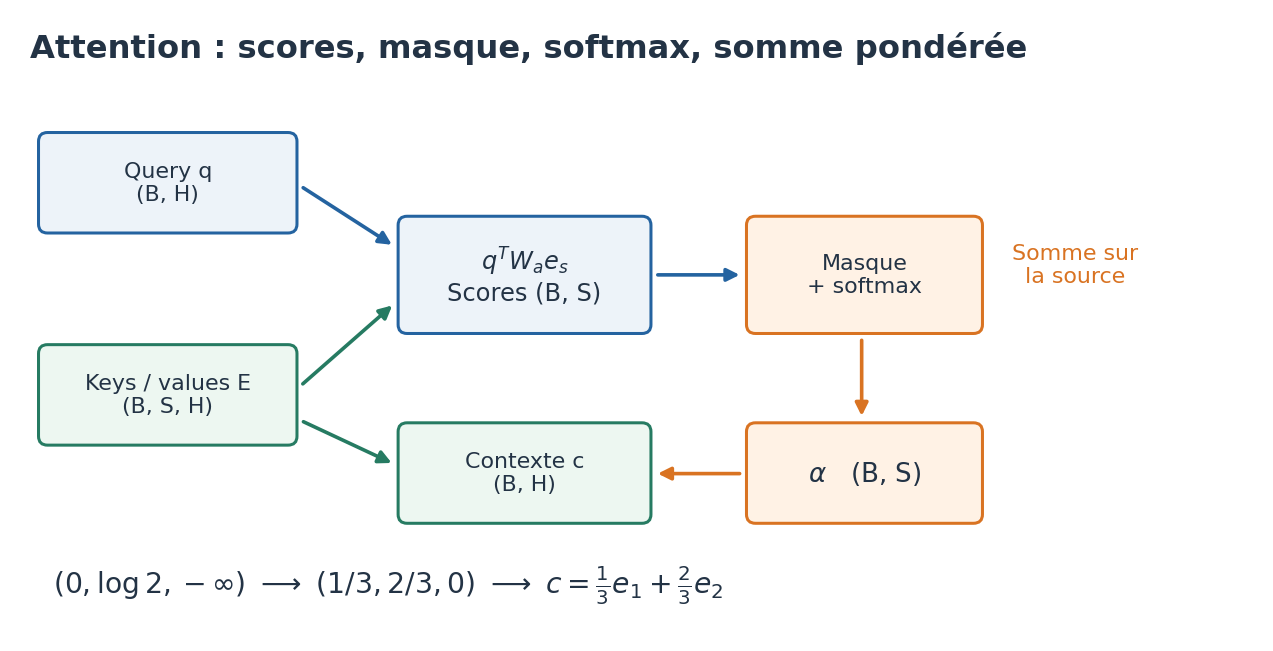

In [ ]:
class BilinearAttention(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.proj = nn.Linear(hidden, hidden, bias=False)

    def forward(self, query, encoder_states, source_mask):
        # Query : (B, H). Une colonne par exemple permet le produit.
        projected_query = self.proj(query)
        query_column = projected_query.unsqueeze(-1)  # (B, H, 1)

        # C4a : comparer la query à chaque position source.
        raise NotImplementedError("C4a : produit query–keys")
        scores = score_columns.squeeze(-1)  # (B, S)

        # Exclure le padding AVANT la normalisation.
        masked_scores = scores.masked_fill(~source_mask, -torch.inf)

        # C4b : la somme porte sur les positions source.
        raise NotImplementedError(
            "C4b : normalisation sur la source"
        )  # (B, S)

        weight_rows = weights.unsqueeze(1)  # (B, 1, S)

        # C4c : combiner les values avec les poids calculés.
        raise NotImplementedError("C4c : somme pondérée des values")
        context = context_rows.squeeze(1)  # (B, H)

        return context, weights


# Vérifier séparément les quatre propriétés de la fonction.
att_test = BilinearAttention(hidden=4)
query_test = torch.randn(2, 4)
memory_test = torch.randn(2, 5, 4)

positions = torch.arange(5).unsqueeze(0)
test_lengths = torch.tensor([3, 5]).unsqueeze(1)
source_mask = positions < test_lengths

context, weights = att_test(query_test, memory_test, source_mask)
assert context.shape == (2, 4)
assert weights.shape == (2, 5)

weight_sums = weights.sum(dim=-1)
assert torch.allclose(weight_sums, torch.ones(2), atol=1e-6)
assert torch.all(weights[~source_mask] == 0)

modified_memory = memory_test.clone()
modified_memory[~source_mask] = 1000
modified_context, _ = att_test(query_test, modified_memory, source_mask)
assert torch.allclose(context, modified_context, atol=1e-6)

print("C4 : formes, poids normalisés et masque validés.")

### 3.3 — Relier l’encoder au decoder

L'encoder doit rendre à la fois sa mémoire de positions et son dernier état valide. `pack_padded_sequence` soustrait le padding au déroulement récurrent ; `pad_packed_sequence` restitue ensuite un tableau rectangulaire pour calculer l'attention. L'état qui initialise le decoder correspond ainsi à la véritable fin de chaque source.

**C5 :** effectuez un pas de `GRUCell` à partir de l'embedding du token précédent et de l'état précédent. Le nouvel état sert de requête pour l'attention ; la tête de sortie reçoit la concaténation de cet état et du contexte. Avant d'exécuter le contrôle, prévoyez la forme des logits : `(B, T_cible, 13)`. Ajouter du padding à droite des sources doit laisser ces logits inchangés.

La fonction `greedy` exprime la génération autonome. Elle commence par BOS, choisit à chaque pas le symbole de score maximal, puis le réinjecte au pas suivant. Les symboles PAD et BOS sont interdits en sortie, car ils ne sont jamais des cibles valides. Lorsqu'un exemple atteint EOS, il est terminé, même si les autres exemples du batch continuent. La limite de quatorze pas ne révèle pas la longueur cible au modèle ; elle empêche seulement un décodage sans fin.

In [ ]:
class Seq2Seq(nn.Module):
    def __init__(self, use_attention, hidden=48, embedding=24):
        super().__init__()
        self.use_attention = use_attention

        self.emb = nn.Embedding(VOCAB, embedding, padding_idx=PAD)
        self.encoder = nn.GRU(embedding, hidden, batch_first=True)
        self.decoder = nn.GRUCell(embedding, hidden)
        self.out = nn.Linear(2 * hidden, VOCAB)

        if use_attention:
            self.attention = BilinearAttention(hidden)
        else:
            self.attention = None

    def encode(self, source, lengths):
        embeddings = self.emb(source)  # (B, S, embedding)

        packed_inputs = pack_padded_sequence(
            embeddings,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        packed_states, final_states = self.encoder(packed_inputs)

        encoder_states, _ = pad_packed_sequence(
            packed_states,
            batch_first=True,
            total_length=source.shape[1],
        )

        source_positions = torch.arange(source.shape[1]).unsqueeze(0)
        source_lengths = lengths.unsqueeze(1)
        source_mask = source_positions < source_lengths

        # Un seul layer : enlever l'axe qui numérote les layers.
        decoder_initial_state = final_states[0]
        return encoder_states, decoder_initial_state, source_mask

    def step(self, token, hidden, encoder_states, source_mask):
        token_embedding = self.emb(token)

        # C5 : actualiser le hidden state à partir du token précédent.
        raise NotImplementedError("C5 : une transition du decoder")

        if self.use_attention:
            context, weights = self.attention(
                hidden, encoder_states, source_mask
            )
        else:
            context = torch.zeros_like(hidden)
            weights = None

        combined_state = torch.cat([hidden, context], dim=-1)
        logits = self.out(combined_state)
        return logits, hidden, weights

    def forward(self, source, lengths, dec_in):
        encoder_states, hidden, source_mask = self.encode(source, lengths)
        output_logits = []

        for step in range(dec_in.shape[1]):
            previous_token = dec_in[:, step]
            logits, hidden, _ = self.step(
                previous_token, hidden, encoder_states, source_mask
            )
            output_logits.append(logits)

        return torch.stack(output_logits, dim=1)

In [ ]:
# Génération autonome : aucune target n'est transmise à cette fonction.
@torch.no_grad()
def greedy(model, source, lengths, max_steps=14):
    model.eval()
    encoder_states, hidden, source_mask = model.encode(source, lengths)

    batch_size = source.shape[0]
    previous_token = source.new_full((batch_size,), BOS)
    finished = torch.zeros(batch_size, dtype=torch.bool)

    predicted_tokens = []
    attention_maps = []

    for step in range(max_steps):
        logits, hidden, weights = model.step(
            previous_token, hidden, encoder_states, source_mask
        )

        # Ces deux symboles ne sont pas des targets valides.
        logits[:, [PAD, BOS]] = -torch.inf
        next_token = logits.argmax(dim=-1)

        # Les exemples déjà terminés ne produisent plus de symbole.
        padding_token = torch.full_like(next_token, PAD)
        next_token = torch.where(finished, padding_token, next_token)
        predicted_tokens.append(next_token)

        if weights is not None:
            attention_maps.append(weights)

        finished = finished | (next_token == EOS)
        previous_token = next_token

        if finished.all():
            break

    predictions = torch.stack(predicted_tokens, dim=1)

    if attention_maps:
        maps = torch.stack(attention_maps, dim=1)
    else:
        maps = None

    return predictions, maps

In [ ]:
# Vérifier les formes et le traitement du padding avant le training.
toy = Seq2Seq(use_attention=True)
toy.eval()

with torch.no_grad():
    logits = toy(src[:2], src_len[:2], dec_in[:2])
    extra_padding = F.pad(src[:2], (0, 3))
    logits_with_padding = toy(extra_padding, src_len[:2], dec_in[:2])

expected_shape = (2, target.shape[1], VOCAB)
assert logits.shape == expected_shape
assert torch.allclose(logits, logits_with_padding, atol=1e-6)
print("C5 : formes et encoder invariant au padding validés.")

**Q7.** Pourquoi faut-il à la fois ignorer PAD dans la loss et masquer PAD dans l'attention ? Comparez ensuite le chemin par lequel la source influence la sortie avec et sans attention.

**Votre réponse à Q7 :** …

### 3.4 — Construire le training et une validation fidèle à la tâche

La boucle suit la même discipline que celle du classifieur, mais la loss porte maintenant sur plusieurs décisions par exemple. Nous aplatissons uniquement les axes batch et temps pour présenter à `cross_entropy` un tableau de scores `(B*T,13)` et un vecteur de cibles `(B*T,)`. L'option `ignore_index=PAD` retire les positions sans cible. La moyenne tient compte du nombre de tokens valides, et non du nombre de cases rectangulaires.

À chaque fin d'epoch, les losses train et validation sont recalculées à paramètres fixes, avec le même teacher forcing. Tous les quatre passages, et avant le premier, nous mesurons aussi la génération autonome sur la validation. Les fonctions ci-dessous séparent ces deux opérations pour que leurs résultats ne soient jamais confondus. Pour l'accuracy token, une position cible manquante est fausse et EOS compte comme une cible. La sequence accuracy exige l'égalité de la séquence complète jusqu'à EOS ; elle sanctionne donc également les arrêts précoces, tardifs ou absents.

**Lire le schéma.** La target et la prédiction de cet exemple ont la même longueur et se terminent correctement par EOS. Un token est pourtant faux. La token accuracy rend compte des trois décisions réussies ; la sequence accuracy exprime l'échec de la réponse entière. À mesure que la longueur augmente, ces deux exigences peuvent s'écarter davantage.

$$A_{\mathrm{tok}}=\frac{\text{tokens corrects}}{\text{tokens cibles valides}},\qquad A_{\mathrm{seq}}=\frac{1}{N}\sum_b\mathbf1[\widehat Y_b=Y_b].$$

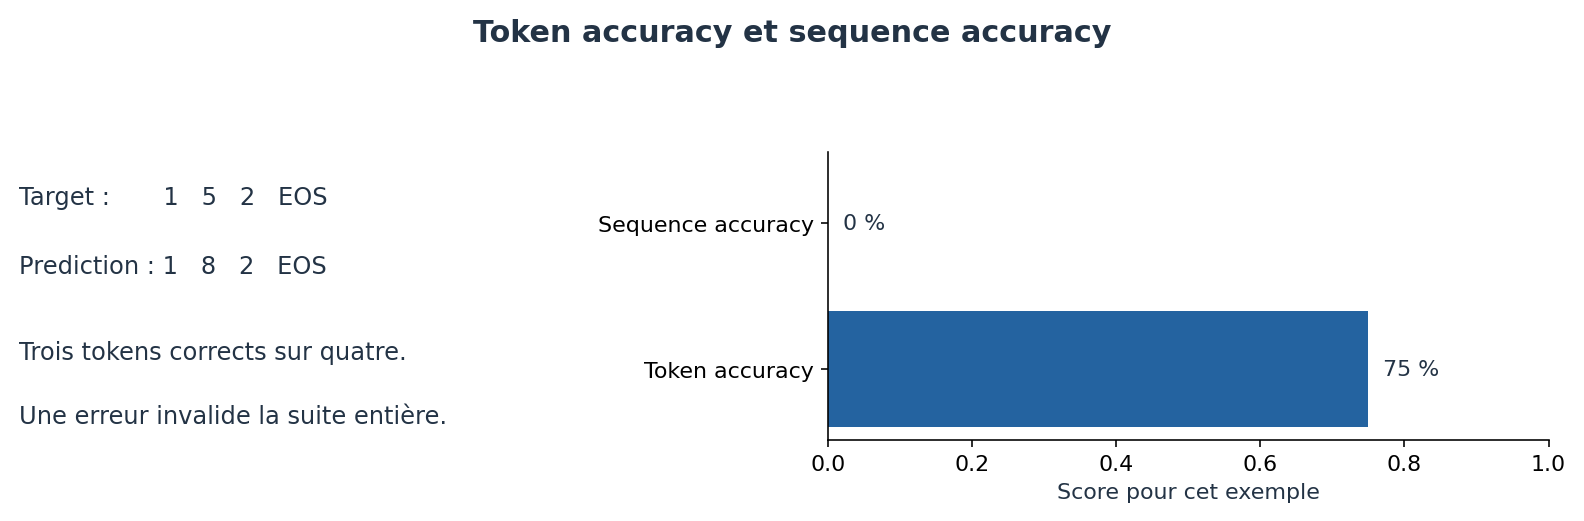

In [ ]:
def until_eos(row):
    values = row.tolist()
    if EOS in values:
        end_position = values.index(EOS) + 1
        return values[:end_position]

    # Sans EOS, la séquence ne sera pas égale à la target complète.
    return values


@torch.no_grad()
def seq_metrics(model, pairs):
    num_exact_sequences = 0
    num_correct_tokens = 0
    num_target_tokens = 0
    num_sequences = 0
    bins = {"3–5": [0, 0], "6–9": [0, 0]}

    for source, lengths, target in seq_loader(pairs):
        predictions, _ = greedy(model, source, lengths)

        for prediction, expected, length in zip(predictions, target, lengths):
            predicted_tokens = until_eos(prediction)
            target_tokens = until_eos(expected)
            is_exact = predicted_tokens == target_tokens

            num_exact_sequences += int(is_exact)
            num_sequences += 1
            num_target_tokens += len(target_tokens)

            for position, expected_token in enumerate(target_tokens):
                if position < len(predicted_tokens):
                    predicted_token = predicted_tokens[position]
                    if predicted_token == expected_token:
                        num_correct_tokens += 1

            if length <= 5:
                length_group = "3–5"
            else:
                length_group = "6–9"
            bins[length_group][0] += int(is_exact)
            bins[length_group][1] += 1

    accuracy_by_length = {}
    for group, counts in bins.items():
        num_correct, num_total = counts
        if num_total > 0:
            accuracy_by_length[group] = num_correct / num_total
        else:
            accuracy_by_length[group] = float("nan")

    return {
        "tokens": num_correct_tokens / num_target_tokens,
        "exact": num_exact_sequences / num_sequences,
        "by_length": accuracy_by_length,
    }

In [ ]:
@torch.no_grad()
def seq_loss(model, pairs):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    for source, lengths, target in seq_loader(pairs):
        decoder_inputs = shifted_targets(target)
        logits = model(source, lengths, decoder_inputs)

        # Aplatir B et T, en conservant l'axe des classes.
        flat_logits = logits.reshape(-1, VOCAB)
        flat_targets = target.reshape(-1)
        batch_loss = F.cross_entropy(
            flat_logits, flat_targets, ignore_index=PAD, reduction="sum"
        )

        valid_positions = target != PAD
        total_loss += batch_loss.item()
        total_tokens += valid_positions.sum().item()

    return total_loss / total_tokens

In [ ]:
def train_seq(use_attention, epochs=16, lr=0.003):
    seed_all(123)
    model = Seq2Seq(use_attention)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    training_loader = seq_loader(train_pairs, shuffle=True)

    initial_metrics = seq_metrics(model, val_pairs)
    history = {
        "train_loss": [],
        "val_loss": [],
        "eval_epoch": [0],
        "exact": [initial_metrics["exact"]],
        "tokens": [initial_metrics["tokens"]],
    }

    for epoch in range(1, epochs + 1):
        model.train()

        for source, lengths, target in training_loader:
            optimizer.zero_grad(set_to_none=True)

            # Forward avec teacher forcing.
            decoder_inputs = shifted_targets(target)
            logits = model(source, lengths, decoder_inputs)

            flat_logits = logits.reshape(-1, VOCAB)
            flat_targets = target.reshape(-1)
            loss = F.cross_entropy(flat_logits, flat_targets, ignore_index=PAD)

            # Backward puis update des paramètres.
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        train_loss = seq_loss(model, train_pairs)
        validation_loss = seq_loss(model, val_pairs)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(validation_loss)

        evaluate_generation = (epoch % 4 == 0) or (epoch == epochs)
        if evaluate_generation:
            metrics = seq_metrics(model, val_pairs)
            history["eval_epoch"].append(epoch)
            history["exact"].append(metrics["exact"])
            history["tokens"].append(metrics["tokens"])

    final_metrics = seq_metrics(model, val_pairs)

    if use_attention:
        model_name = "Avec attention"
    else:
        model_name = "Sans attention"

    print(
        f"{model_name} | tokens {final_metrics['tokens']:.1%}"
        f" | suites exactes {final_metrics['exact']:.1%}"
    )
    print("Accuracy de suite par longueur :", final_metrics["by_length"])

    return model, history, final_metrics

### 3.5 — Fixer le protocole, suivre les deux trainings

Nous conservons seize epochs pour les deux modèles et comparons leur état final. Les paramètres communs partent des mêmes valeurs, grâce à une initialisation ordonnée identiquement et à la même seed. Une fois la première update effectuée, leurs trajectoires se séparent naturellement. Le graphique de gauche suit la log-vraisemblance conditionnée par le passé correct ; celui de droite suit la qualité d'une réponse produite de bout en bout.

Avant de regarder les résultats, écrivez une hypothèse sur l'effet de la longueur. Puis examinez si le tableau par tranches de longueur la soutient. Si les losses train et validation restent élevées ensemble, l'optimisation ou la capacité demandent à être examinées ; si elles s'écartent fortement, la généralisation devient la question principale. Pour proposer un réglage, choisissez une seule modification — learning rate, hidden size ou nombre d'epochs — et annoncez l'effet attendu sur les deux courbes. Le protocole de comparaison présent reste fixé pendant les deux trainings.

Les mesures aux epochs 4, 8, 12 et 16 vous permettent de suivre un même modèle au cours de sa progression. Commencez par lire le point à l'epoch 4 comme si le training s'était arrêté là : quel diagnostic auriez-vous porté et qu'auriez-vous essayé ? Confrontez ensuite cette proposition à la suite du plot. Une valeur `seq_epochs = 4` permet de reproduire ce budget court ; `seq_epochs = 16` est le réglage conseillé pour mener l'expérience complète. Le point essentiel est de ne pas changer simultanément la durée du training, le learning rate et la hidden size : vous obtiendriez peut-être un meilleur score sans savoir quelle idée a réellement été mise à l'épreuve.

**Votre prédiction à partir de l'epoch 4, puis sa confrontation aux epochs suivantes :** …

In [ ]:
seq_epochs = (
    16  # 4 pour un budget court ; 16 pour suivre la progression complète
)
baseline, history_base, metrics_base = train_seq(False, epochs=seq_epochs)
att_model, history_att, metrics_att = train_seq(True, epochs=seq_epochs)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for color, name, hist in [
    ("tab:blue", "Sans attention", history_base),
    ("tab:orange", "Avec attention", history_att),
]:
    ep = np.arange(1, len(hist["train_loss"]) + 1)
    axes[0].plot(ep, hist["train_loss"], color=color, label=name + " / train")
    axes[0].plot(
        ep, hist["val_loss"], "--", color=color, label=name + " / val"
    )
    axes[1].plot(
        hist["eval_epoch"],
        hist["exact"],
        "o-",
        color=color,
        label=name + " / suites",
    )
    axes[1].plot(
        hist["eval_epoch"],
        hist["tokens"],
        "x--",
        color=color,
        label=name + " / tokens",
    )
axes[0].set(xlabel="Epoch", ylabel="CE en teacher forcing")
axes[1].set(
    xlabel="Epoch", ylabel="Accuracy autonome, validation", ylim=(0, 1.03)
)
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 3.6 — Lire une carte d’attention à la lumière des prédictions

Une carte d'attention n'est pas une décoration du résultat ; elle représente les poids employés pour composer les contextes successifs. Choisissons une source de longueur 9. Les colonnes de la carte désignent les positions sources, les lignes les pas du decoder. Les labels verticales sont les symboles effectivement prédits, y compris lorsque la réponse comporte une erreur. Les carrés blancs marquent les positions attendues si le modèle procède par lecture inversée.

Regardez simultanément la source, la cible, la prédiction et la carte. Un poids élevé doit être interprété en relation avec le symbole produit à ce pas. Lorsque des chiffres se répètent, plusieurs positions peuvent se ressembler ; les états du GRU portent en outre leur contexte. La ligne EOS mérite une lecture particulière : elle signifie que la réponse s'achève et ne correspond pas à la copie d'un chiffre source.

Résistez ici à la tentation de retenir uniquement une belle antidiagonale. Une image convaincante peut illustrer un mécanisme, mais elle ne résume pas les 240 sources de validation. Commencez par le score global, consultez les résultats par longueur, puis employez la carte pour comprendre un cas particulier. Si ce cas échoue, localisez la première erreur : le poids est-il diffus, décalé, ou concentré sur une position dont la représentation semble malgré tout mal exploitée ? Ces observations n'apportent pas immédiatement une cause certaine ; elles rendent votre prochaine expérience plus précise.

**Lire le schéma.** Cette antidiagonale est un alignement idéal proposé avant l'observation. Elle donne un repère pour interroger la carte apprise, et non une forme que l'on doit absolument retrouver. Lisez ensemble la position, son token et la prédiction correspondante ; un état encoder contient déjà des informations sur son préfixe.

$$s_{\mathrm{attendu}}(t)=\ell-t+1,\qquad 1\leq t\leq\ell.$$

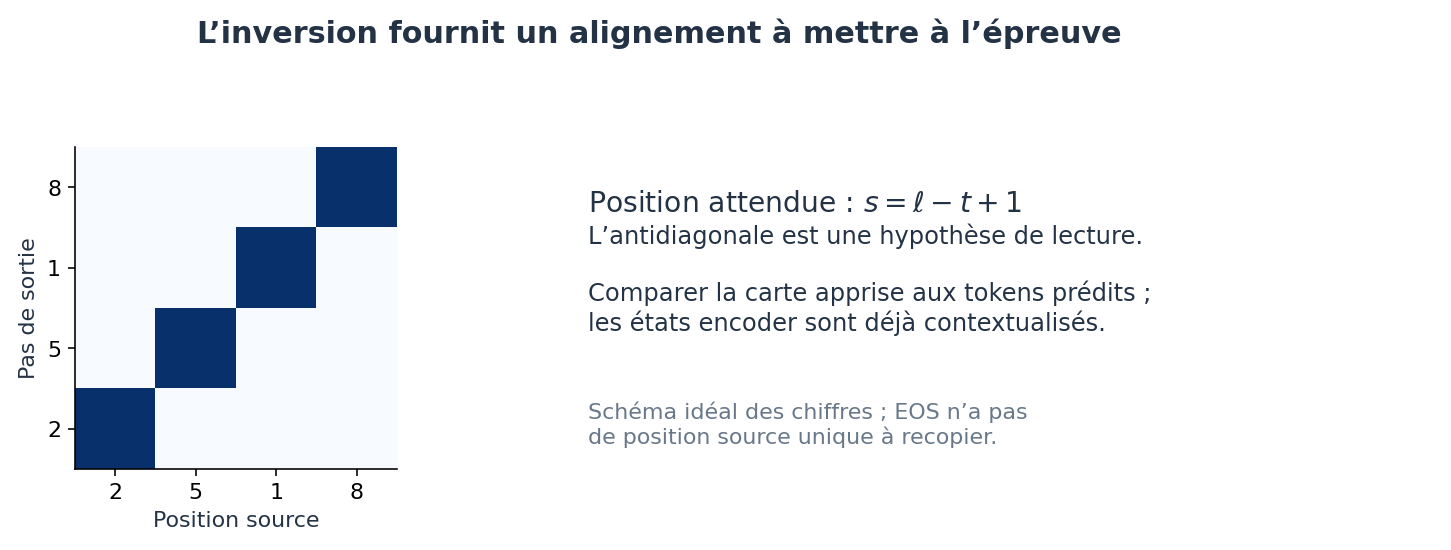

In [ ]:
sample = next(pair for pair in val_pairs if len(pair[0]) == 9)
s, ll, tgt = seq_collate([sample])
pred, maps = greedy(att_model, s, ll)
print("Source :", " ".join(map(token_name, s[0])))
print("Cible  :", " ".join(map(token_name, tgt[0])))
print("Prédit :", " ".join(map(token_name, pred[0])))
fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(maps[0].numpy(), vmin=0, vmax=1, cmap="viridis", aspect="auto")
ax.set_xticks(range(s.shape[1]), [token_name(v) for v in s[0]])
ax.set_yticks(range(pred.shape[1]), [token_name(v) for v in pred[0]])
for t in range(min(int(ll[0]), pred.shape[1])):
    ax.plot(int(ll[0]) - 1 - t, t, "s", ms=9, mfc="none", mec="white")
ax.set(
    xlabel="Position source (label = chiffre)",
    ylabel="Pas decoder (label = prédiction)",
)
ax.grid(False)
fig.colorbar(im, ax=ax, label="Poids d’attention")
plt.tight_layout()
plt.show()

### 3.7 — Comprendre le chemin direct ouvert au gradient

Reprenons une question de la première séance : par où une erreur peut-elle atteindre une représentation passée ? Nous isolons ici la mémoire encoder $E$ sous la forme d'un tenseur feuille indépendant. Une sonde lit seulement le dernier état ; l'autre lit le contexte d'attention au cinquième pas de sortie. Les poids d'attention sont fixés à leurs valeurs observées et détachés du graphe. Cette construction isole le trajet qui passe par les **valeurs**, sans y mêler celui qui passerait par les scores.

Pour $S_{att}=\mathbf1^T\sum_s\alpha_se_s$, on a $\partial S_{att}/\partial e_s=\alpha_s\mathbf1$, donc une norme $\alpha_s\sqrt H$. Pour $S_{fin}=\mathbf1^Te_\ell$, seul le dernier état reçoit un gradient direct. Le graphique teste cette différence. Dans le réseau complet, les états encoder sont reliés entre eux par la récurrence : les états plus anciens peuvent donc aussi recevoir un gradient indirect. Gardez cette distinction présente lorsque vous expliquerez la figure.

**Lire le schéma.** Le bleu décrit le forward de l'encoder. L'orange montre le retour depuis l'état final, puis vers les états précédents. Le vert ajoute les accès permis par l'attention. Dans la sonde du code, détacher la mémoire et fixer les poids d'attention permet d'isoler ces accès directs, sans les confondre avec le gradient total du réseau.

$$S=\mathbf1^{\mathsf T}\sum_s\alpha_se_s,\qquad\frac{\partial S}{\partial e_s}=\alpha_s\mathbf1\quad\text{si les poids }\alpha_s\text{ sont fixés}.$$

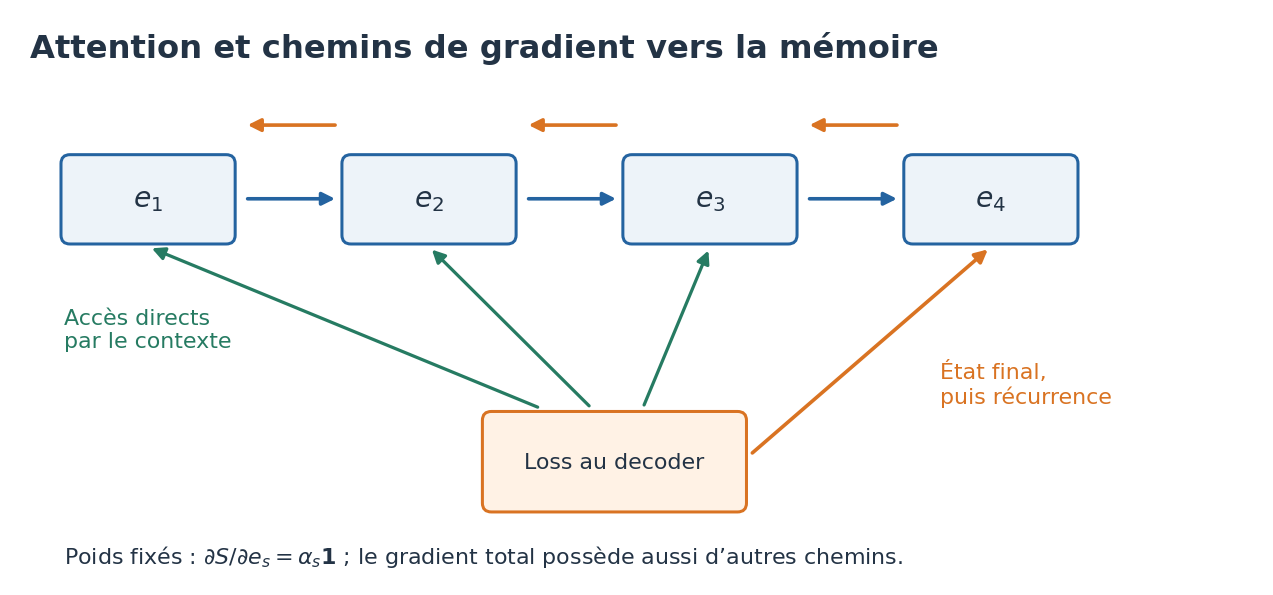

In [ ]:
with torch.no_grad():
    enc, _, _ = att_model.encode(s, ll)
probe_step = min(4, maps.shape[1] - 1)
alpha = maps[:, probe_step, :].detach()
memory = enc.detach().clone().requires_grad_(True)
last_probe = memory[:, -1].sum()
grad_last = torch.autograd.grad(last_probe, memory)[0].norm(dim=-1)[0]
memory = enc.detach().clone().requires_grad_(True)
context_probe = (alpha.unsqueeze(-1) * memory).sum()
grad_att = torch.autograd.grad(context_probe, memory)[0].norm(dim=-1)[0]
assert torch.allclose(grad_att, alpha[0] * math.sqrt(enc.shape[-1]), atol=1e-6)
assert torch.count_nonzero(grad_last[:-1]) == 0
fig, ax = plt.subplots(figsize=(8, 3))
pos = np.arange(s.shape[1])
ax.bar(
    pos - 0.18, grad_last.numpy(), width=0.36, label="Lecture du dernier état"
)
ax.bar(
    pos + 0.18,
    grad_att.numpy(),
    width=0.36,
    label="Lecture avec attention, poids fixés",
)
ax.set(
    xlabel="Position source",
    ylabel="Norme du gradient direct",
    title=f"Sonde au pas decoder {probe_step+1}",
)
ax.legend()
plt.tight_layout()
plt.show()

### 3.8 — Faire parler les observations sans leur demander davantage qu’elles ne disent

**Q8.** Comparez losses train/validation, accuracy token et sequence accuracy pour les deux modèles. Expliquez un écart entre ces mesures. Proposez un réglage unique, en précisant le symptôme observé, la modification choisie et l'effet attendu. Que permet réellement de conclure la comparaison des longueurs 3–5 et 6–9 ?

**Q9.** La carte suit-elle approximativement l'alignement attendu pour une inversion ? Appuyez votre réponse sur deux pas de décodage et sur les symboles produits. Pourquoi une carte d'attention ne constitue-t-elle pas, à elle seule, une démonstration causale de l'importance des pixels ou des symboles d'entrée ?

**Q10.** Expliquez le graphique des gradients directs, puis décrivez le chemin qui subsiste vers les états anciens dans le modèle complet sans attention. Quel accès l'attention ajoute-t-elle ? Pourquoi cet accès ne garantit-il pas un signal uniformément réparti sur toute la source ?

**Vos réponses à Q8–Q10 :** …

**Travail à remettre.** Enregistrez le notebook avec les neuf lignes complétées, les figures exécutées et les réponses Q1–Q10. Terminez par quelques phrases reliant les trois exercices : ce que l'état transporte vers l'avant, ce que le gradient transmet vers l'arrière, et ce que l'attention rend directement accessible à la production d'une réponse.

## Sources scientifiques et documentation

La description du dataset, les propriétés de l'autodifférentiation et la définition des cellules récurrentes peuvent être confrontées aux ressources suivantes. Les deux articles donnent le cadre scientifique des difficultés d'apprentissage et de l'accès par attention à la mémoire de l'encoder.

- [Digits — documentation scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html).
- [Pascanu, Mikolov et Bengio (2013), *On the difficulty of training Recurrent Neural Networks*](https://arxiv.org/abs/1211.5063).
- [Bahdanau, Cho et Bengio (2015), *Neural Machine Translation by Jointly Learning to Align and Translate*](https://arxiv.org/abs/1409.0473). L'article développe une attention additive ; la fonction construite ici utilise un score bilinéaire.
- [PyTorch — GRUCell](https://docs.pytorch.org/docs/stable/generated/torch.nn.GRUCell.html), [séquences compactées](https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pack_padded_sequence.html), [clipping de la norme des gradients](https://docs.pytorch.org/docs/stable/generated/torch.nn.utils.clip_grad_norm_.html).